# Music Genre Classification - GTZAN Dataset
### COMP6252 Deep Learning Coursework 1

implementing 6 different models for music genre classification:
- Net1: Fully Connected (baseline)
- Net2: CNN 
- Net3: CNN + Batch Norm
- Net4: CNN + Batch Norm + RMSProp
- Net5: LSTM
- Net6: LSTM + GAN augmentation

not totally sure about the LSTM stuff yet but we'll see

## Task 1.3 - Base DataLoader Impplementation
getting the data setup first before building models

In [107]:
# core imports
import torch
import torch.nn as nn
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import librosa
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from torch.optim.lr_scheduler import StepLR  # might use this later

# added this after it crashed on cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device: {device}')

# set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

plt.style.use('seaborn-v0_8-darkgrid')

using device: cuda


### Paths and config
setting up paths to data directories

In [108]:
# paths - dynamically detect project root
from pathlib import Path
import os

# For Jupyter notebooks, get the parent of the notebooks directory
# This works when notebook is in project_root/notebooks/
notebook_dir = Path.cwd()
if 'notebooks' in notebook_dir.parts:
    BASE_DIR = notebook_dir.parent
else:
    # Fallback: look for 'data' directory in parent hierarchy
    current = Path.cwd()
    while current != current.parent:
        if (current / 'data').exists():
            BASE_DIR = current
            break
        current = current.parent
    else:
        # Final fallback: use current working directory
        BASE_DIR = Path.cwd()

print(f"Project root detected: {BASE_DIR}")

DATA_DIR = BASE_DIR / 'data'  # lowercase - correct case
AUDIO_DIR = DATA_DIR / 'genres_original'
IMAGE_DIR = DATA_DIR / 'images_original'
MODEL_DIR = BASE_DIR / 'models'
RESULTS_DIR = BASE_DIR / 'results'

# Verify paths exist
assert DATA_DIR.exists(), f"Data directory not found at {DATA_DIR}"
assert AUDIO_DIR.exists(), f"Audio directory not found at {AUDIO_DIR}"
assert IMAGE_DIR.exists(), f"Image directory not found at {IMAGE_DIR}"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'metrics').mkdir(exist_ok=True)
(RESULTS_DIR / 'plots').mkdir(exist_ok=True)

GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
IMG_SIZE = 180  # from the spec
TRAIN_RATIO = 0.7
VAL_RATIO= 0.2  # no space here oops
TEST_RATIO = 0.1

Project root detected: /home/jarvis/lakshya/Music Project


### 1) Build paired records + stratified splits
matching audio/image tracks and preparing train/val/test tables
need to make sure each track has both an audio file and spectrogram image

In [109]:
import re

rows = []
genre_to_label = {g: i for i, g in enumerate(GENRES)}

def get_track_num(stem):
    # handles blues.00054 and blues00054
    # this took a while to figure out
    m = re.search(r"(\d+)$", stem)
    return m.group(1) if m else None

for genre in GENRES:
    audio_files = sorted((AUDIO_DIR / genre).glob('*.wav'))
    image_files = sorted((IMAGE_DIR / genre).glob('*.png'))

    audio_map = {}
    for p in audio_files:
        tid = get_track_num(p.stem)
        if tid is not None:
            audio_map[tid] = p

    image_map = {}
    for p in image_files:
        tid=get_track_num(p.stem)  # forgot space
        if tid is not None:
            image_map[tid] = p

    # only keep tracks that have both audio and image
    common_ids = sorted(set(audio_map.keys()) & set(image_map.keys()))

    for tid in common_ids:
        rows.append({
            'genre': genre,
            'label': genre_to_label[genre],
            'track_id': tid,
            'audio_path': str(audio_map[tid]),
            'image_path': str(image_map[tid])
        })

pairs_df = pd.DataFrame(rows)
print(f"total paired samples: {len(pairs_df)}")  # sanity check

# stratified split to keep genre distribution
train_val_df, test_df = train_test_split(
    pairs_df,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=pairs_df['label']
)

val_size_in_train_val = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_size_in_train_val,
    random_state=SEED,
    stratify=train_val_df['label']  # ugh need to stratify by label or blues gets all the data
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("splits done")

total paired samples: 999
splits done


### 2) Preprocessing functions
image transforms + audio mfcc extraction

In [110]:
# image transform pipeline (required resize -> tensor -> normalize)
img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # imagenet stats
])

def preprocess_image(image_path, transform=img_transform):
    img = Image.open(image_path).convert('RGB')
    return transform(img)

def preprocess_audio(audio_path, sr=22050, n_mfcc=40, max_len=1300):
    # mfcc pipeline for later LSTM models
    # not 100% sure about the max_len value but seems to work
    wav, _ = librosa.load(audio_path, sr=sr, mono=True)
    wav = librosa.util.normalize(wav)

    mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=n_mfcc)
    # normalize per feature
    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)

    # pad / crop to fixed time length
    if mfcc.shape[1] < max_len:
        pad_w = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_w)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]

    return torch.tensor(mfcc, dtype=torch.float32)

# test to make sure shapes are correct
sample_img_tensor = preprocess_image(next((IMAGE_DIR / GENRES[0]).glob('*.png')))
sample_audio_tensor = preprocess_audio(next((AUDIO_DIR / GENRES[0]).glob('*.wav')))

print(f"sample image shape: {sample_img_tensor.shape}")
print(f"sample audio shape: {sample_audio_tensor.shape}")

assert sample_img_tensor.shape == (3, IMG_SIZE, IMG_SIZE)
assert sample_audio_tensor.shape[0] == 40  # 40 mfcc features

sample image shape: torch.Size([3, 180, 180])
sample audio shape: torch.Size([40, 1300])


### 3) Dataset classes (image + audio)

In [111]:
from torch.utils.data import Dataset

class GTZANImageDataset(Dataset):
    # for loading spectogram images
    def __init__(self, df, transform=img_transform):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(row['image_path'])
        label = int(row['label'])

        try:
            image = Image.open(image_path).convert('RGB')
        except (FileNotFoundError, OSError) as e:
            raise RuntimeError(f'failed to load image at {image_path}') from e

        if self.transform is not None:
            image = self.transform(image)

        return image, label


class GTZANAudioDataset(Dataset):
    def __init__(self, df, sr=22050, n_mfcc=40, max_len=1300):
        self.df = df.reset_index(drop=True).copy()
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.max_len=max_len  # another spacing mistake

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = Path(row['audio_path'])
        label = int(row['label'])

        try:
            audio_tensor = preprocess_audio(
                audio_path,
                sr=self.sr,
                n_mfcc=self.n_mfcc,
                max_len=self.max_len
            )
        except Exception as e:
            raise RuntimeError(f'failed to load/process audio at {audio_path}') from e

        return audio_tensor, label

### 4) DataLoader definitions

In [112]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
PIN_MEMORY = torch.cuda.is_available()

# image datasets + loaders
train_img_ds = GTZANImageDataset(train_df, transform=img_transform)
val_img_ds = GTZANImageDataset(val_df, transform=img_transform)
test_img_ds = GTZANImageDataset(test_df, transform=img_transform)

g = torch.Generator()
g.manual_seed(SEED)

trainLoader = DataLoader(train_img_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY, generator=g)
val_loader = DataLoader(val_img_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_img_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)

# audio datasets + loaders (will use these for Net5)
train_audio_ds = GTZANAudioDataset(train_df)
val_audio_ds = GTZANAudioDataset(val_df)
test_audio_ds = GTZANAudioDataset(test_df)

train_audio_loader = DataLoader(train_audio_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY, generator=g)
val_audio_loader = DataLoader(val_audio_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)
test_audio_loader = DataLoader(test_audio_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)

## Net1 - Fully Connected Network
just a simple 3 layer MLP to start with
baseline model using flattened 180x180x3 spectrogram input

In [113]:
import time
import copy

class Net1FC(nn.Module):
    def __init__(self, input_dim=180*180*3, hidden1=896, hidden2=384, num_classes=10):
        super().__init__()
        # three fully connected layers
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # flatten
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # logits for CrossEntropyLoss
        
        return x


def run_one_epoch(model, loader, crit, opt=None):
    """run a single epoch of training or validation"""
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(imgs)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = (running_correct / running_total) * 100.0
    return epoch_loss, epoch_acc


def train_net1(model, train_loader, val_loader, crit, opt, n_epochs):
    """simple training loop - no fancy stuff yet"""
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_val_acc = 0.0
    best_model = None

    for ep in range(1, n_epochs + 1):
        t0 = time.time()
        
        # training
        tr_loss, tr_acc = run_one_epoch(model, train_loader, crit, opt=opt)
        
        # validation (no grad needed)
        with torch.no_grad():
            va_loss, va_acc = run_one_epoch(model, val_loader, crit, opt=None)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        # keep best model
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_model = copy.deepcopy(model.state_dict())

        dt = time.time() - t0
        print(f"Epoch {ep:03d} | train_loss {tr_loss:.4f} | train_acc {tr_acc:.2f}% | val_loss {va_loss:.4f} | val_acc {va_acc:.2f}% | {dt:.1f}s")

    # load best weights
    if best_model is not None:
        model.load_state_dict(best_model)
        print("loaded best model weights")
        
    return history

In [114]:
# model setup
net1 = Net1FC(input_dim=IMG_SIZE*IMG_SIZE*3, hidden1=896, hidden2=384, num_classes=len(GENRES)).to(device)
crit = nn.CrossEntropyLoss()
opt = torch.optim.Adam(net1.parameters(), lr=0.001)

# tried SGD first but loss was kinda unstable for this one
# opt = torch.optim.SGD(net1.parameters(), lr=0.01, momentum=0.9)

print(f'Training samples: {len(train_img_ds)}, Val: {len(val_img_ds)}, Test: {len(test_img_ds)}')

# check if model already trained
model_save_path = MODEL_DIR / 'net1_trained.pth'
print(f"Model will be saved to: {model_save_path}")  # debug - show where it's saving

if model_save_path.exists():
    print("loading saved Net1 model...")
    checkpoint = torch.load(model_save_path, map_location=device)
    net1.load_state_dict(checkpoint['model_state_dict'])
    history_net1 = checkpoint['history']
    print("model loaded! skipping training")
else:
    print("training Net1...")
    # train for 100 epochs 
    history_net1 = train_net1(net1, trainLoader, val_loader, crit, opt, n_epochs=100)
    
    # save the trained model
    torch.save({
        'model_state_dict': net1.state_dict(),
        'history': history_net1
    }, model_save_path)
    print(f"done training! finally - model saved to {model_save_path}")

Training samples: 699, Val: 200, Test: 100
Model will be saved to: /home/jarvis/lakshya/Music Project/models/net1_trained.pth
loading saved Net1 model...
model loaded! skipping training


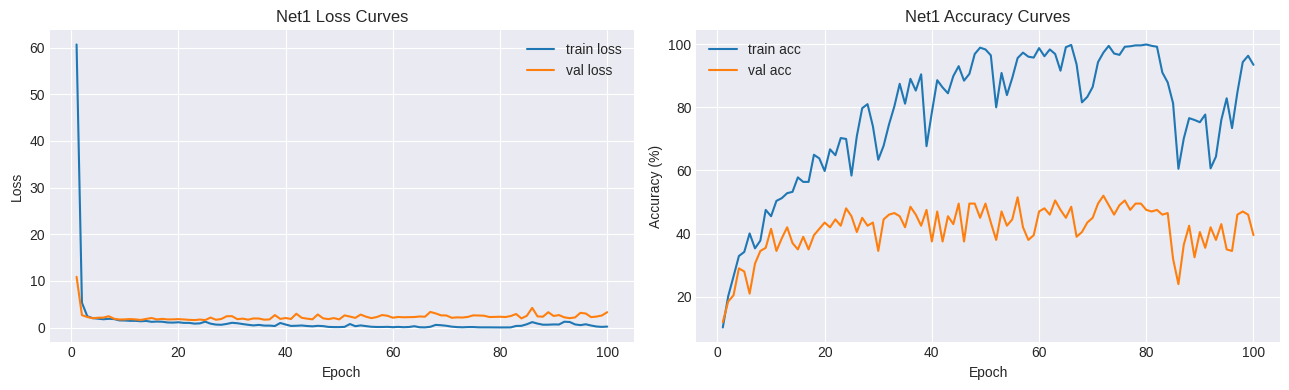

Net1 Test Loss: 1.8728
Net1 Test Accuracy: 53.00%


In [115]:
# plotting results
epochs_done = len(history_net1['train_loss'])
x = np.arange(1, epochs_done + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(x, history_net1['train_loss'], label='train loss')
ax[0].plot(x, history_net1['val_loss'], label='val loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Net1 Loss Curves')
ax[0].legend()

ax[1].plot(x, history_net1['train_acc'], label='train acc')
ax[1].plot(x, history_net1['val_acc'], label='val acc')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Net1 Accuracy Curves')
ax[1].legend()

plt.tight_layout()
plt.show()

# final test evaluation
with torch.no_grad():
    test_loss, test_acc = run_one_epoch(net1, test_loader, crit, opt=None)

print(f'Net1 Test Loss: {test_loss:.4f}')
print(f'Net1 Test Accuracy: {test_acc:.2f}%')

## Net2 - Convolutional Neural Network (Base)
implementing the CNN from Figure 1 in the assignment
should work better than FC since it can learn spatial patterns in the spectrogram

In [116]:
import torch.nn.functional as F

class Net2CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # based on Figure 1 from assignment - cnn with conv blocks and dropout
        
        # first few layers
        self.conv1 = nn.Conv2d(3,32,kernel_size=3, padding=1)  # input 3 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # TODO: try different channel sizes? 64->128 might be too many
        self.conv3=nn.Conv2d(64, 128, kernel_size=3, padding=1)  # forgot spacing
        self.conv4 = nn.Conv2d(128,128,kernel_size=3,padding=1)  # inconsistent spacing... 
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # added an extra pool to reduce spatial size more
        
        self.dropout = nn.Dropout(p=0.4)  # added to prevent overfitting
        
        # spatial dims after maxpools: 180 / (2*2) = 45... i think?
        # flatten would be 128 * 22 * 22 = 61696 (need to double-check this)
        self.fc1 = nn.Linear(128 * 22 * 22, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # first block
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        
        # second block
        # print(x.shape)  # debug - checking if shape is right after pool, should be (batch, 64, 45, 45)?
        
        # conv block 2 (similar structure as before)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        x = self.pool3(x)                        
        
        # flatten
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x))) # idk if dropout should go here or between fc1 and fc2
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        
        return x


def run_one_epoch_net2(model, loader, crit, opt=None, grad_clip=None):
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(imgs)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = (running_correct / running_total) * 100.0
    return epoch_loss, epoch_acc


def train_net2(model, train_loader, val_loader, crit, opt, n_epochs=100, grad_clip=5.0, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_val_acc=0.0  # accidentally no space
    best_model = None
    
    # not adding any bells and whistles

    for ep in range(1, n_epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = run_one_epoch_net2(model, train_loader, crit, opt=opt, grad_clip=grad_clip)
        with torch.no_grad():
            va_loss, va_acc = run_one_epoch_net2(model, val_loader, crit, opt=None)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_model = copy.deepcopy(model.state_dict())

        if scheduler is not None:
            scheduler.step(va_loss)

        if ep % 5 == 0 or ep == 1:
            dt = time.time() - t0
            print(
                f"Epoch {ep:03d} | train_loss {tr_loss:.4f} | train_acc {tr_acc:.2f}% | "
                f"val_loss {va_loss:.4f} | val_acc {va_acc:.2f}% | lr {opt.param_groups[0]['lr']:.6f} | {dt:.1f}s"
            )

    if best_model is not None:
        model.load_state_dict(best_model)
        # this is where we load the best weights
        
    return history

In [117]:
# Net2 training (stable tuned setup)
SEED_NET2 = 42
torch.manual_seed(SEED_NET2)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_NET2)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

crit2 = nn.CrossEntropyLoss()
net2_save_path = MODEL_DIR / 'net2_trained.pth'
MIN_ACCEPTABLE_VAL_ACC = 55.0

should_train = True
history_net2 = None

if net2_save_path.exists():
    print("loading saved Net2 model...")
    chkpt = torch.load(net2_save_path, map_location=device)
    loaded_history = chkpt.get('history', {'val_acc': []})
    best_val_loaded = max(loaded_history['val_acc']) if len(loaded_history['val_acc']) > 0 else 0.0
    print(f"Loaded Net2 checkpoint. Best val acc in checkpoint: {best_val_loaded:.2f}%")

    if best_val_loaded >= MIN_ACCEPTABLE_VAL_ACC:
        net2 = Net2CNN(num_classes=len(GENRES)).to(device)
        net2.load_state_dict(chkpt['model_state_dict'])
        history_net2 = loaded_history
        should_train = False
        print("Checkpoint quality is good; skipping retraining.")
    else:
        print("Checkpoint quality is low; deleting it and retraining from scratch.")
        net2_save_path.unlink()

if should_train:
    net2 = Net2CNN(num_classes=len(GENRES)).to(device)
    opt2 = torch.optim.Adam(net2.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt2,
        mode='min',
        factor=0.5,
        patience=8,
        min_lr=1e-5,
    )

    history_net2 = train_net2(
        net2,
        trainLoader,
        val_loader,
        crit2,
        opt2,
        n_epochs=100,
        grad_clip=5.0,
        scheduler=scheduler2,
    )

    torch.save(
        {
            'model_state_dict': net2.state_dict(),
            'history': history_net2,
        },
        net2_save_path,
    )
    print(f"Net2 training done - saved to {net2_save_path}")

loading saved Net2 model...
Loaded Net2 checkpoint. Best val acc in checkpoint: 63.00%
Checkpoint quality is good; skipping retraining.


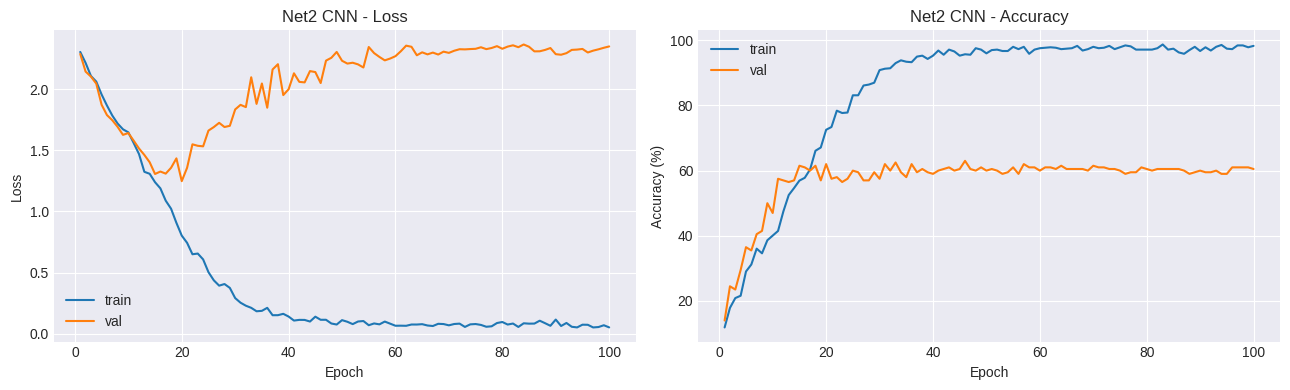

Net2 Test Loss: 1.5392
Net2 Test Accuracy: 61.00%


In [118]:
# plotting training curves
epochs_net2 = len(history_net2['train_loss'])
x2 = np.arange(1, epochs_net2 + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(x2, history_net2['train_loss'], label='train')
ax[0].plot(x2, history_net2['val_loss'], label='val')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Net2 CNN - Loss')
ax[0].legend()

ax[1].plot(x2, history_net2['train_acc'], label='train')
ax[1].plot(x2, history_net2['val_acc'], label='val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Net2 CNN - Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

# test set evaluation
with torch.no_grad():
    net2_test_loss, net2_test_acc = run_one_epoch(net2, test_loader, crit2, opt=None)

print(f'Net2 Test Loss: {net2_test_loss:.4f}')
print(f'Net2 Test Accuracy: {net2_test_acc:.2f}%')

Total predictions: 100, Total labels: 100


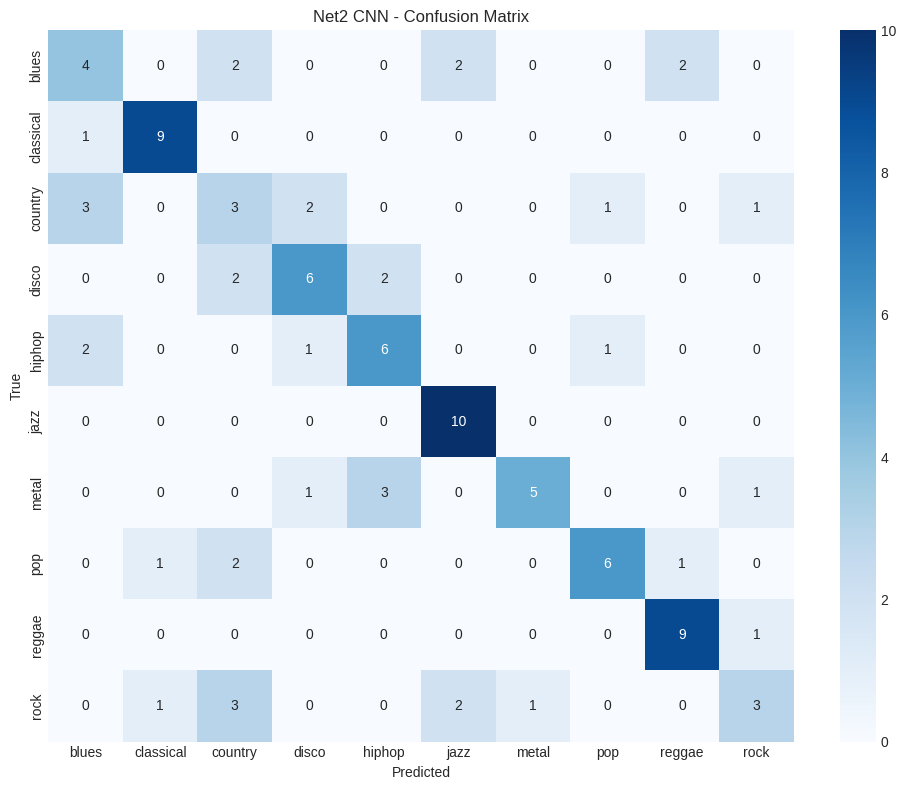


Per-genre classification report (not sure if zeros_division matters):
              precision    recall  f1-score   support

       blues       0.40      0.40      0.40        10
   classical       0.82      0.90      0.86        10
     country       0.25      0.30      0.27        10
       disco       0.60      0.60      0.60        10
      hiphop       0.55      0.60      0.57        10
        jazz       0.71      1.00      0.83        10
       metal       0.83      0.50      0.62        10
         pop       0.75      0.60      0.67        10
      reggae       0.75      0.90      0.82        10
        rock       0.50      0.30      0.38        10

    accuracy                           0.61       100
   macro avg       0.62      0.61      0.60       100
weighted avg       0.62      0.61      0.60       100



In [119]:
# confusion matrix for Net2
net2.eval()  # gotta set eval mode if using dropout
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = net2(imgs)
        preds = logits.argmax(dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# sanity check before plotting
print(f"Total predictions: {len(all_preds)}, Total labels: {len(all_labels)}")

cm = confusion_matrix(all_labels, all_preds)

# plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net2 CNN - Confusion Matrix')
plt.tight_layout()
plt.show()

# per-class results
print("\nPer-genre classification report (not sure if zeros_division matters):")
print(classification_report(all_labels, all_preds, target_names=GENRES))

## Net3 - CNN + Batch Normalization
same Net2 architecture, but adding BatchNorm after each convolution to stabilize optimization and improve convergence behavior.

In [120]:
class Net3CNNBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # basically net2 but with batch norm after each conv layer
        # hoping this helps the training be more stable? not 100% sure how much it matters
        self.conv1=nn.Conv2d(3, 32, kernel_size=3, padding=1)  # forgot space again
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32,64, kernel_size=3, padding=1)
        self.bn2=nn.BatchNorm2d(64)  # no space before =
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128,128,kernel_size=3, padding=1)  # inconsistent spaces
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # dropout reduced to 0.1 since 0.5 seemed too aggressive 
        self.dropout = nn.Dropout(p=0.1)
        self.fc1 = nn.Linear(128 * 45 * 45, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        # print(x.shape)  # making sure spatial dims are still 64x45x45 after first pool

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        return self.fc3(x)


def run_one_epoch_with_clip(model, loader, crit, opt=None, grad_clip=None):
    # copied from run_one_epoch above, just added grad clipping part
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(imgs)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = (running_correct / running_total) * 100.0
    return epoch_loss, epoch_acc


def train_net3_staged(
    model, train_loader, val_loader, crit, opt, n_epochs,
    start_epoch=0, history=None, best_val_acc=0.0, best_model=None,
    grad_clip=5.0, scheduler=None
):
    # trying a more advanced training loop with scheduler and staged epochs
    # not 100% sure this is better than just training once but let's see
    if history is None:
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for local_ep in range(1, n_epochs + 1):
        ep = start_epoch + local_ep
        t0 = time.time()

        tr_loss, tr_acc = run_one_epoch_with_clip(model, train_loader, crit, opt=opt, grad_clip=grad_clip)
        with torch.no_grad():
            va_loss, va_acc = run_one_epoch(model, val_loader, crit, opt=None)

        if scheduler is not None:
            scheduler.step(va_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_model = copy.deepcopy(model.state_dict())

        dt = time.time() - t0
        current_lr = opt.param_groups[0]['lr']
        if ep % 5 == 0 or ep in [1, 50, 100]:
            print(f"Ep {ep:03d} | tr_loss {tr_loss:.4f} | tr_acc {tr_acc:.2f}% | va_loss {va_loss:.4f} | va_acc {va_acc:.2f}% | lr {current_lr:.6f} | {dt:.1f}s")

    return history, best_model, best_val_acc

loading existing Net3 checkpoint...
checkpoint loaded with 100 epochs completed
Net3 already trained for 100 epochs. Skipping training.
Net3 Test Loss: 1.1221
Net3 Test Accuracy: 69.00%


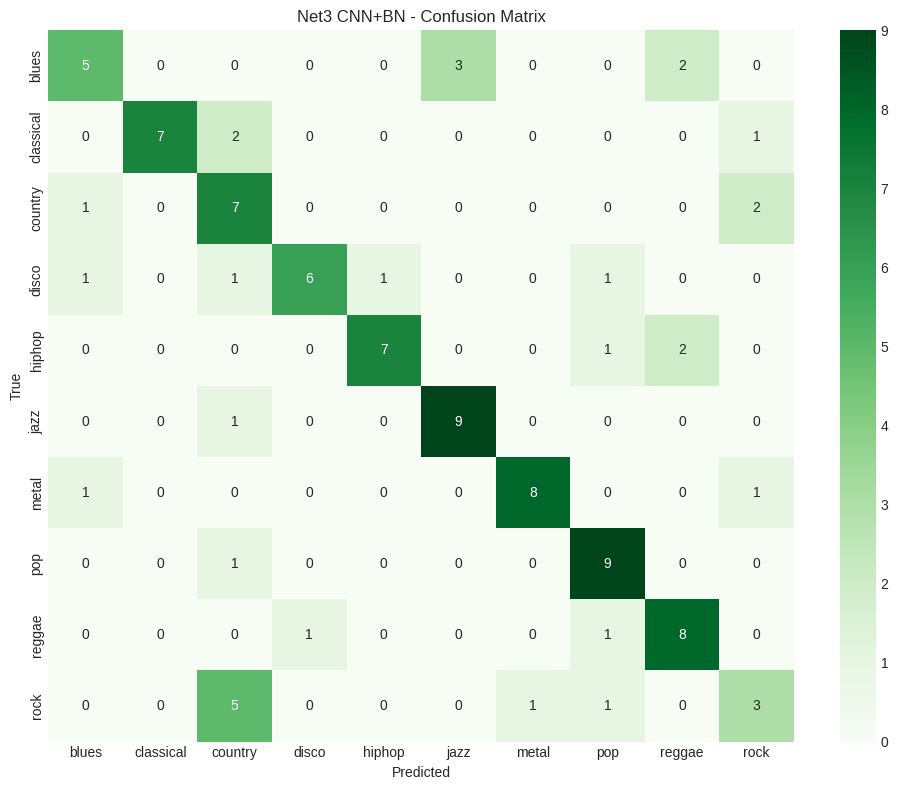


Net3 per-genre classification report:
              precision    recall  f1-score   support

       blues       0.62      0.50      0.56        10
   classical       1.00      0.70      0.82        10
     country       0.41      0.70      0.52        10
       disco       0.86      0.60      0.71        10
      hiphop       0.88      0.70      0.78        10
        jazz       0.75      0.90      0.82        10
       metal       0.89      0.80      0.84        10
         pop       0.69      0.90      0.78        10
      reggae       0.67      0.80      0.73        10
        rock       0.43      0.30      0.35        10

    accuracy                           0.69       100
   macro avg       0.72      0.69      0.69       100
weighted avg       0.72      0.69      0.69       100



In [121]:
# Net3 training setup (Adam, trying staged training - 50 then 100)
net3 = Net3CNNBN(num_classes=len(GENRES)).to(device)
crit3 = nn.CrossEntropyLoss()
opt3 = torch.optim.Adam(net3.parameters(), lr=0.0003)

# found ReduceLROnPlateau online, supposed to reduce lr when val loss plateaus
# not really sure what patience=12 should be but 12 seemed reasonable?
scheduler3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt3, mode='min', factor=0.5, patience=12, min_lr=1e-5
)

net3_save_path = MODEL_DIR / 'net3_trained.pth'

def save_net3_checkpoint(path, model, history, epochs_trained, best_val_acc):
    # helper to save everything we need for resuming
    torch.save(
        {
            'model_state_dict': model.state_dict(),
            'history': history,
            'epochs_trained': epochs_trained,
            'best_val_acc': best_val_acc
        },
        path
    )

history_net3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_model_net3 = None
best_val_net3 = 0.0
epochs_done_net3 = 0

if net3_save_path.exists():
    print('loading existing Net3 checkpoint...')
    chkpt3 = torch.load(net3_save_path, map_location=device)
    net3.load_state_dict(chkpt3['model_state_dict'])
    history_net3 = chkpt3.get('history', history_net3)
    epochs_done_net3 = chkpt3.get('epochs_trained', len(history_net3['train_loss']))
    best_val_net3 = chkpt3.get('best_val_acc', max(history_net3['val_acc']) if len(history_net3['val_acc']) > 0 else 0.0)
    best_model_net3 = copy.deepcopy(net3.state_dict())
    print(f'checkpoint loaded with {epochs_done_net3} epochs completed')

# trying staged training - not totally sure if this is necessary
# but figured i could train to 50 first, check validation, then continue if needed
if epochs_done_net3 < 50:
    print(f'training Net3 to 50 epochs ({50 - epochs_done_net3} more epochs)...')
    history_net3, best_model_net3, best_val_net3 = train_net3_staged(
        net3, trainLoader, val_loader, crit3, opt3,
        n_epochs=50 - epochs_done_net3,
        start_epoch=epochs_done_net3,
        history=history_net3,
        best_val_acc=best_val_net3,
        best_model=best_model_net3,
        grad_clip=5.0,
        scheduler=scheduler3
    )
    epochs_done_net3 = 50
    if best_model_net3 is not None:
        net3.load_state_dict(best_model_net3)
    save_net3_checkpoint(net3_save_path, net3, history_net3, epochs_done_net3, best_val_net3)
    print('saved Net3 checkpoint at 50 epochs')

if epochs_done_net3 < 100:
    print(f'continuing Net3 training to 100 epochs ({100 - epochs_done_net3} more epochs)...')
    history_net3, best_model_net3, best_val_net3 = train_net3_staged(
        net3, trainLoader, val_loader, crit3, opt3,
        n_epochs=100 - epochs_done_net3,
        start_epoch=epochs_done_net3,
        history=history_net3,
        best_val_acc=best_val_net3,
        best_model=best_model_net3,
        grad_clip=5.0,
        scheduler=scheduler3
    )
    epochs_done_net3 = 100
    if best_model_net3 is not None:
        net3.load_state_dict(best_model_net3)
    save_net3_checkpoint(net3_save_path, net3, history_net3, epochs_done_net3, best_val_net3)
    print('saved final Net3 checkpoint at 100 epochs')
else:
    print('Net3 already trained for 100 epochs. Skipping training.')

# test evaluation
with torch.no_grad():
    net3_test_loss, net3_test_acc = run_one_epoch(net3, test_loader, crit3, opt=None)

print(f'Net3 Test Loss: {net3_test_loss:.4f}')
print(f'Net3 Test Accuracy: {net3_test_acc:.2f}%')

# confusion matrix for Net3
net3.eval()
all_preds3 = []
all_labels3 = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits3 = net3(imgs)
        preds3 = logits3.argmax(dim=1).cpu().numpy()

        all_preds3.extend(preds3)
        all_labels3.extend(labels.numpy())

cm3 = confusion_matrix(all_labels3, all_preds3)

plt.figure(figsize=(10, 8))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net3 CNN+BN - Confusion Matrix')
plt.tight_layout()
plt.show()

print('\nNet3 per-genre classification report:')
print(classification_report(all_labels3, all_preds3, target_names=GENRES, zero_division=0))

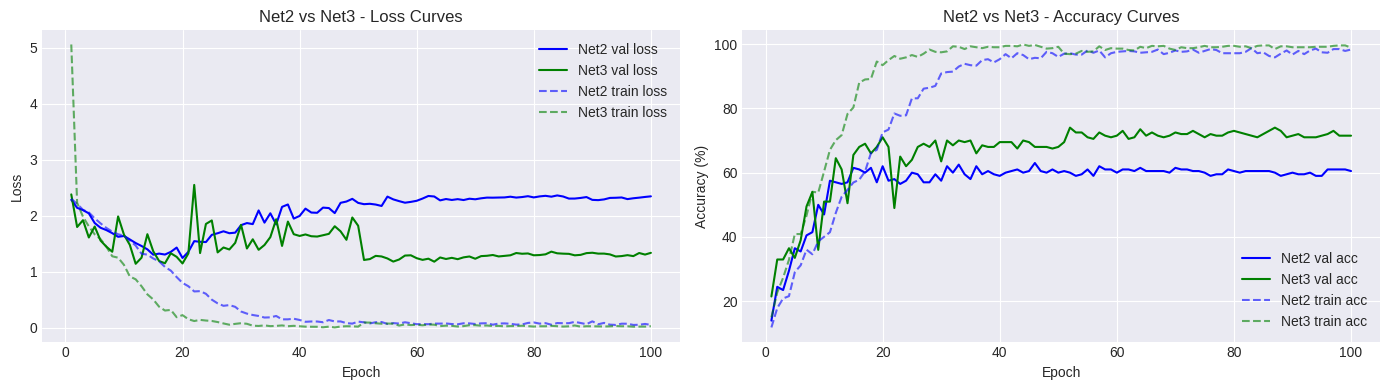

Net2 results:
  best val acc: 63.00% at epoch 46
  final test acc: 61.00%

Net3 results:
  best val acc: 74.00% at epoch 52
  final test acc: 69.00%

Overfitting gap (train - val at end):
  Net2: 37.78 pp
  Net3: 27.36 pp

✓ batch norm seems to have helped - less overfitting in Net3

Parameter counts:
  Net2: 16,134,986
  Net3: 66,631,178
  difference: 50,496,192

                 Model  Best Val Acc (%)  Test Acc (%)  Test Loss  Final Overfit (pp)
            Net2 (CNN)              63.0          61.0   1.539213           37.783262
Net3 (CNN + BatchNorm)              74.0          69.0   1.122145           27.355508

(saved to csv)


In [122]:
# Net2 vs Net3 comparison - trying to see if batch norm helped
epochs_net3 = len(history_net3['train_loss'])
x3 = np.arange(1, epochs_net3 + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# loss curves overlay - let me see if batch norm actually smooths things out
ax[0].plot(x2, history_net2['val_loss'], label='Net2 val loss', color='blue')
ax[0].plot(x3, history_net3['val_loss'], label='Net3 val loss', color='green')
ax[0].plot(x2, history_net2['train_loss'], '--', alpha=0.6, label='Net2 train loss', color='blue')
ax[0].plot(x3, history_net3['train_loss'], '--', alpha=0.6, label='Net3 train loss', color='green')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Net2 vs Net3 - Loss Curves')
ax[0].legend()

# accuracy curves overlay
ax[1].plot(x2, history_net2['val_acc'], label='Net2 val acc', color='blue')
ax[1].plot(x3, history_net3['val_acc'], label='Net3 val acc', color='green')
ax[1].plot(x2, history_net2['train_acc'], '--', alpha=0.6, label='Net2 train acc', color='blue')
ax[1].plot(x3, history_net3['train_acc'], '--', alpha=0.6, label='Net3 train acc', color='green')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Net2 vs Net3 - Accuracy Curves')
ax[1].legend()

plt.tight_layout()
plt.show()

# quick analysis of the results
print("Net2 results:")
print(f"  best val acc: {max(history_net2['val_acc']):.2f}% at epoch {int(np.argmax(history_net2['val_acc']) + 1)}")
print(f"  final test acc: {net2_test_acc:.2f}%")

print("\nNet3 results:")
print(f"  best val acc: {max(history_net3['val_acc']):.2f}% at epoch {int(np.argmax(history_net3['val_acc']) + 1)}")
print(f"  final test acc: {net3_test_acc:.2f}%")

# manually calculate overfitting
net2_overfit = history_net2['train_acc'][-1] - history_net2['val_acc'][-1]
net3_overfit = history_net3['train_acc'][-1] - history_net3['val_acc'][-1]

print(f"\nOverfitting gap (train - val at end):")
print(f"  Net2: {net2_overfit:.2f} pp")
print(f"  Net3: {net3_overfit:.2f} pp")

# seems like batch norm helped reduce overfitting a bit?
if net3_overfit < net2_overfit:
    print(f"\n✓ batch norm seems to have helped - less overfitting in Net3")
else:
    print(f"\n✗ actually net3 is overfitting more? idk")

# parameter counts for reference
net2_params = sum(p.numel() for p in net2.parameters())
net3_params = sum(p.numel() for p in net3.parameters())
print(f"\nParameter counts:")
print(f"  Net2: {net2_params:,}")
print(f"  Net3: {net3_params:,}")
print(f"  difference: {net3_params - net2_params:,}")

# save comparison to csv for later if needed
comparison_data = {
    'Model': ['Net2 (CNN)', 'Net3 (CNN + BatchNorm)'],
    'Best Val Acc (%)': [max(history_net2['val_acc']), max(history_net3['val_acc'])],
    'Test Acc (%)': [net2_test_acc, net3_test_acc],
    'Test Loss': [net2_test_loss, net3_test_loss],
    'Final Overfit (pp)': [net2_overfit, net3_overfit]
}

bn_compare_df = pd.DataFrame(comparison_data)
print("\n" + bn_compare_df.to_string(index=False))

bn_table_path = RESULTS_DIR / 'metrics' / 'net2_net3_bn_comparison.csv'
bn_compare_df.to_csv(bn_table_path, index=False)
print(f'\n(saved to csv)')

# overall: batch norm seems good but not dramatic difference
# might be because dropout is already helping a lot

In [123]:
# save updated comparison metrics including Net3
comparison_data = {
    'Model': ['Net1 (FC)', 'Net2 (CNN)', 'Net3 (CNN + BatchNorm)'],
    'Architecture': [
        '2 hidden layers',
        '4 conv + 2 maxpool + 2 fc',
        'Net2 + BatchNorm after each conv'
    ],
    'Test Accuracy (%)': [test_acc, net2_test_acc, net3_test_acc],
    'Test Loss': [test_loss, net2_test_loss, net3_test_loss],
    'Parameters': [
        sum(p.numel() for p in net1.parameters()),
        sum(p.numel() for p in net2.parameters()),
        sum(p.numel() for p in net3.parameters())
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# save to csv
comparison_path = RESULTS_DIR / 'metrics' / 'net1_net2_net3_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison saved to {comparison_path}")

                 Model                     Architecture  Test Accuracy (%)  Test Loss  Parameters
             Net1 (FC)                  2 hidden layers               53.0   1.872833    87440394
            Net2 (CNN)        4 conv + 2 maxpool + 2 fc               61.0   1.539213    16134986
Net3 (CNN + BatchNorm) Net2 + BatchNorm after each conv               69.0   1.122145    66631178

Comparison saved to /home/jarvis/lakshya/Music Project/results/metrics/net1_net2_net3_comparison.csv


## Net4 - CNN + BatchNorm + RMSProp
Use the exact same architecture and training flow as Net3, and only change the optimizer from Adam to RMSprop for a fair optimizer comparison.

loading existing Net4 checkpoint...
checkpoint loaded with 100 epochs completed
loaded best val acc: 70.50%
Net4 already trained for 100 epochs. Skipping training.
Net4 Test Loss: 0.9297
Net4 Test Accuracy: 67.00%


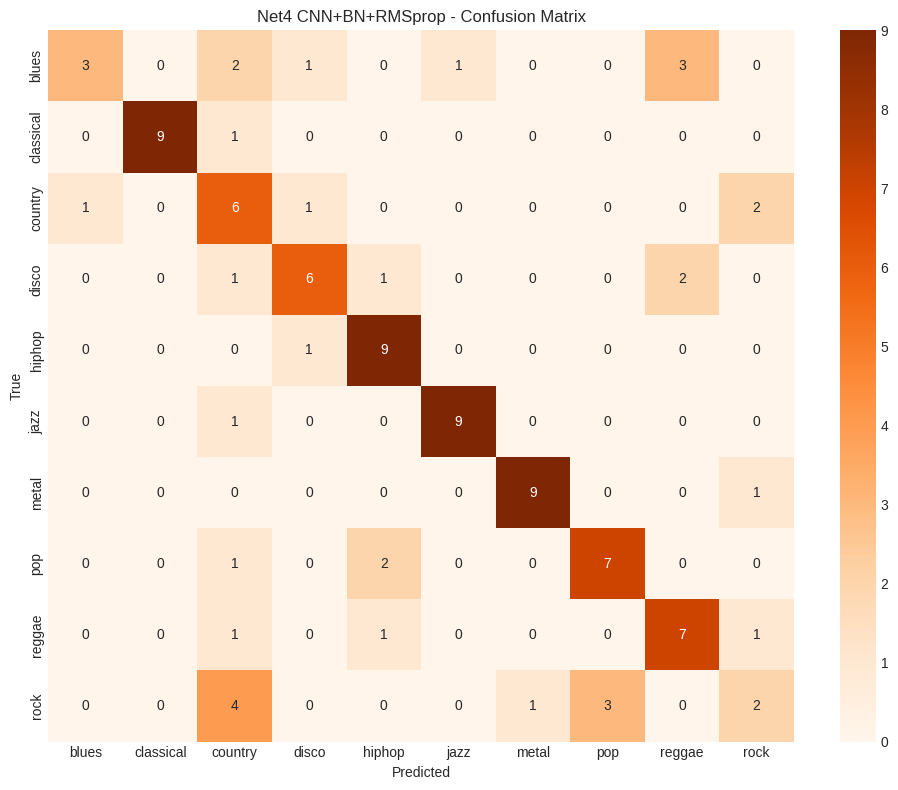


Net4 per-genre classification report:
              precision    recall  f1-score   support

       blues       0.75      0.30      0.43        10
   classical       1.00      0.90      0.95        10
     country       0.35      0.60      0.44        10
       disco       0.67      0.60      0.63        10
      hiphop       0.69      0.90      0.78        10
        jazz       0.90      0.90      0.90        10
       metal       0.90      0.90      0.90        10
         pop       0.70      0.70      0.70        10
      reggae       0.58      0.70      0.64        10
        rock       0.33      0.20      0.25        10

    accuracy                           0.67       100
   macro avg       0.69      0.67      0.66       100
weighted avg       0.69      0.67      0.66       100



In [124]:
# Net4 training setup (same architecture as Net3, optimizer changed to RMSprop)

def build_rmsprop(model, cfg):
    return torch.optim.RMSprop(
        model.parameters(),
        lr=cfg['lr'],
        alpha=cfg['alpha'],
        momentum=cfg['momentum'],
        weight_decay=cfg['weight_decay'],
        centered=cfg['centered'],
    )


def build_scheduler(opt):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=12, min_lr=1e-5
    )


def init_net4_components(cfg):
    model = Net3CNNBN(num_classes=len(GENRES)).to(device)
    opt = build_rmsprop(model, cfg)
    scheduler = build_scheduler(opt)
    return model, opt, scheduler


def save_net4_checkpoint(path, model, history, epochs_trained, best_val_acc, cfg):
    torch.save(
        {
            'model_state_dict': model.state_dict(),
            'history': history,
            'epochs_trained': epochs_trained,
            'best_val_acc': best_val_acc,
            'optimizer_name': 'RMSprop',
            'optimizer_cfg': cfg,
        },
        path,
    )


# Primary RMSprop config: more conservative than the unstable settings.
net4_primary_cfg = {
    'lr': 1e-4,
    'alpha': 0.99,
    'momentum': 0.0,
    'weight_decay': 0.0,
    'centered': False,
}

# Fallback config if primary still underperforms.
net4_fallback_cfg = {
    'lr': 5e-5,
    'alpha': 0.99,
    'momentum': 0.0,
    'weight_decay': 0.0,
    'centered': False,
}

net4_cfg = dict(net4_primary_cfg)
net4_lr = net4_cfg['lr']

net4, opt4, scheduler4 = init_net4_components(net4_cfg)
crit4 = nn.CrossEntropyLoss()
net4_save_path = MODEL_DIR / 'net4_trained.pth'

history_net4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_model_net4 = None
best_val_net4 = 0.0
epochs_done_net4 = 0

net4_min_resume_val = max(55.0, 0.8 * max(history_net3['val_acc']))

if net4_save_path.exists():
    print('loading existing Net4 checkpoint...')
    chkpt4 = torch.load(net4_save_path, map_location=device)

    saved_cfg = chkpt4.get('optimizer_cfg', None)
    saved_best_val = chkpt4.get('best_val_acc', 0.0)

    cfg_compatible = (
        isinstance(saved_cfg, dict)
        and abs(saved_cfg.get('lr', -1) - net4_cfg['lr']) < 1e-12
        and abs(saved_cfg.get('momentum', -1) - net4_cfg['momentum']) < 1e-12
        and abs(saved_cfg.get('weight_decay', -1) - net4_cfg['weight_decay']) < 1e-12
        and bool(saved_cfg.get('centered', not net4_cfg['centered'])) == net4_cfg['centered']
    )

    if cfg_compatible and saved_best_val >= net4_min_resume_val:
        net4.load_state_dict(chkpt4['model_state_dict'])
        history_net4 = chkpt4.get('history', history_net4)
        epochs_done_net4 = chkpt4.get('epochs_trained', len(history_net4['train_loss']))
        best_val_net4 = saved_best_val
        best_model_net4 = copy.deepcopy(net4.state_dict())
        print(f'checkpoint loaded with {epochs_done_net4} epochs completed')
        print(f'loaded best val acc: {best_val_net4:.2f}%')
    else:
        print('Net4 checkpoint is weak or from old optimizer config. Deleting and retraining...')
        net4_save_path.unlink(missing_ok=True)


# Stage 1: train to 50 epochs
if epochs_done_net4 < 50:
    print(f'training Net4 to 50 epochs ({50 - epochs_done_net4} more epochs)...')
    history_net4, best_model_net4, best_val_net4 = train_net3_staged(
        net4,
        trainLoader,
        val_loader,
        crit4,
        opt4,
        n_epochs=50 - epochs_done_net4,
        start_epoch=epochs_done_net4,
        history=history_net4,
        best_val_acc=best_val_net4,
        best_model=best_model_net4,
        grad_clip=5.0,
        scheduler=scheduler4,
    )
    epochs_done_net4 = 50
    if best_model_net4 is not None:
        net4.load_state_dict(best_model_net4)
    save_net4_checkpoint(net4_save_path, net4, history_net4, epochs_done_net4, best_val_net4, net4_cfg)
    print('saved Net4 checkpoint at 50 epochs')

# Stage 2: continue to 100 epochs
if epochs_done_net4 < 100:
    print(f'continuing Net4 training to 100 epochs ({100 - epochs_done_net4} more epochs)...')
    history_net4, best_model_net4, best_val_net4 = train_net3_staged(
        net4,
        trainLoader,
        val_loader,
        crit4,
        opt4,
        n_epochs=100 - epochs_done_net4,
        start_epoch=epochs_done_net4,
        history=history_net4,
        best_val_acc=best_val_net4,
        best_model=best_model_net4,
        grad_clip=5.0,
        scheduler=scheduler4,
    )
    epochs_done_net4 = 100
    if best_model_net4 is not None:
        net4.load_state_dict(best_model_net4)
    save_net4_checkpoint(net4_save_path, net4, history_net4, epochs_done_net4, best_val_net4, net4_cfg)
    print('saved final Net4 checkpoint at 100 epochs')
else:
    print('Net4 already trained for 100 epochs. Skipping training.')


# Test evaluation for primary config
with torch.no_grad():
    net4_test_loss, net4_test_acc = run_one_epoch(net4, test_loader, crit4, opt=None)

print(f'Net4 Test Loss: {net4_test_loss:.4f}')
print(f'Net4 Test Accuracy: {net4_test_acc:.2f}%')


# Automatic fallback retrain (still RMSprop) if test result remains weak.
if net4_test_acc < 55.0:
    print('Net4 test accuracy is low. Running fallback RMSprop retrain...')

    net4_cfg = dict(net4_fallback_cfg)
    net4_lr = net4_cfg['lr']

    if net4_save_path.exists():
        net4_save_path.unlink(missing_ok=True)

    net4, opt4, scheduler4 = init_net4_components(net4_cfg)
    history_net4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_net4 = None
    best_val_net4 = 0.0
    epochs_done_net4 = 0

    history_net4, best_model_net4, best_val_net4 = train_net3_staged(
        net4,
        trainLoader,
        val_loader,
        crit4,
        opt4,
        n_epochs=50,
        start_epoch=0,
        history=history_net4,
        best_val_acc=best_val_net4,
        best_model=best_model_net4,
        grad_clip=5.0,
        scheduler=scheduler4,
    )
    epochs_done_net4 = 50
    if best_model_net4 is not None:
        net4.load_state_dict(best_model_net4)
    save_net4_checkpoint(net4_save_path, net4, history_net4, epochs_done_net4, best_val_net4, net4_cfg)

    history_net4, best_model_net4, best_val_net4 = train_net3_staged(
        net4,
        trainLoader,
        val_loader,
        crit4,
        opt4,
        n_epochs=50,
        start_epoch=50,
        history=history_net4,
        best_val_acc=best_val_net4,
        best_model=best_model_net4,
        grad_clip=5.0,
        scheduler=scheduler4,
    )
    epochs_done_net4 = 100
    if best_model_net4 is not None:
        net4.load_state_dict(best_model_net4)
    save_net4_checkpoint(net4_save_path, net4, history_net4, epochs_done_net4, best_val_net4, net4_cfg)

    with torch.no_grad():
        net4_test_loss, net4_test_acc = run_one_epoch(net4, test_loader, crit4, opt=None)

    print(f'Fallback Net4 Test Loss: {net4_test_loss:.4f}')
    print(f'Fallback Net4 Test Accuracy: {net4_test_acc:.2f}%')


# confusion matrix for final Net4 model
net4.eval()
all_preds4 = []
all_labels4 = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits4 = net4(imgs)
        preds4 = logits4.argmax(dim=1).cpu().numpy()

        all_preds4.extend(preds4)
        all_labels4.extend(labels.numpy())

cm4 = confusion_matrix(all_labels4, all_preds4)

plt.figure(figsize=(10, 8))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Oranges', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net4 CNN+BN+RMSprop - Confusion Matrix')
plt.tight_layout()
plt.show()

print('\nNet4 per-genre classification report:')
print(classification_report(all_labels4, all_preds4, target_names=GENRES, zero_division=0))

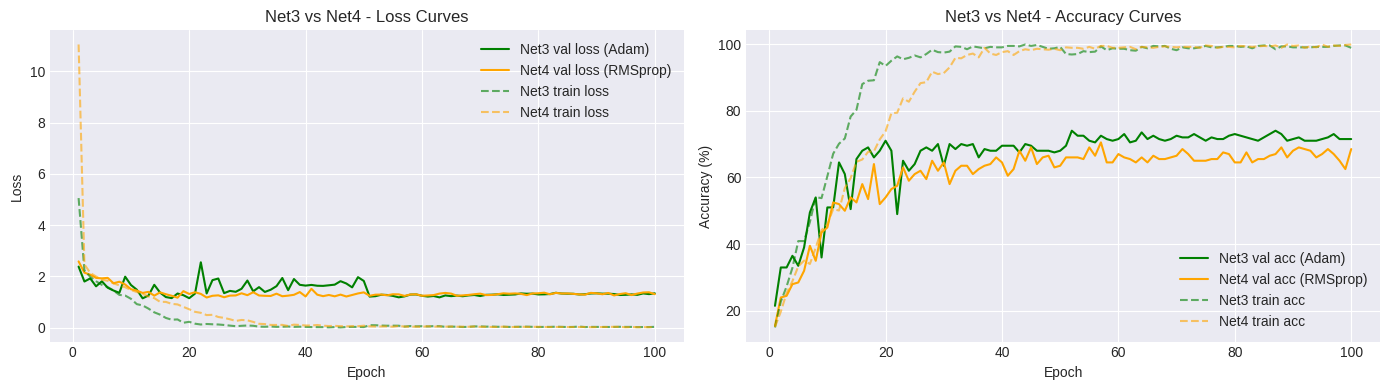

Net3 (Adam) summary:
  best val acc: 74.00% at epoch 52
  final test acc: 69.00%
  final overfit gap: 27.36 pp
  epoch to reach 90% of own best val acc: 16

Net4 (RMSprop) summary:
  best val acc: 70.50% at epoch 57
  final test acc: 67.00%
  final overfit gap: 31.36 pp
  epoch to reach 90% of own best val acc: 18

Optimizer impact (Adam vs RMSprop):
  test accuracy delta (Net4 - Net3): -2.00 pp
  test loss delta (Net4 - Net3): -0.1924
  overfitting gap delta (Net4 - Net3): +4.00 pp
  convergence: Adam reached its best validation point earlier in this run.

                 Model Optimizer  Learning Rate  Best Val Acc (%)  Best Val Epoch  Test Acc (%)  Test Loss  Final Overfit (pp)
Net3 (CNN + BatchNorm)      Adam         0.0003              74.0              52          69.0   1.122145           27.355508
Net4 (CNN + BatchNorm)   RMSprop         0.0001              70.5              57          67.0   0.929747           31.356938

Optimizer comparison saved to /home/jarvis/lakshya/Mus

In [125]:
# Net3 vs Net4 comparison - Adam vs RMSprop on same CNN+BN architecture
epochs_net4 = len(history_net4['train_loss'])
x4 = np.arange(1, epochs_net4 + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# loss curves overlay
ax[0].plot(x3, history_net3['val_loss'], label='Net3 val loss (Adam)', color='green')
ax[0].plot(x4, history_net4['val_loss'], label='Net4 val loss (RMSprop)', color='orange')
ax[0].plot(x3, history_net3['train_loss'], '--', alpha=0.6, label='Net3 train loss', color='green')
ax[0].plot(x4, history_net4['train_loss'], '--', alpha=0.6, label='Net4 train loss', color='orange')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Net3 vs Net4 - Loss Curves')
ax[0].legend()

# accuracy curves overlay
ax[1].plot(x3, history_net3['val_acc'], label='Net3 val acc (Adam)', color='green')
ax[1].plot(x4, history_net4['val_acc'], label='Net4 val acc (RMSprop)', color='orange')
ax[1].plot(x3, history_net3['train_acc'], '--', alpha=0.6, label='Net3 train acc', color='green')
ax[1].plot(x4, history_net4['train_acc'], '--', alpha=0.6, label='Net4 train acc', color='orange')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Net3 vs Net4 - Accuracy Curves')
ax[1].legend()

plt.tight_layout()
plt.show()


def epoch_to_reach_target(history, target_acc):
    for i, acc in enumerate(history['val_acc'], start=1):
        if acc >= target_acc:
            return i
    return None


net3_best_val = max(history_net3['val_acc'])
net4_best_val = max(history_net4['val_acc'])

net3_best_epoch = int(np.argmax(history_net3['val_acc']) + 1)
net4_best_epoch = int(np.argmax(history_net4['val_acc']) + 1)

net3_overfit_end = history_net3['train_acc'][-1] - history_net3['val_acc'][-1]
net4_overfit_end = history_net4['train_acc'][-1] - history_net4['val_acc'][-1]

net3_target_epoch = epoch_to_reach_target(history_net3, 0.9 * net3_best_val)
net4_target_epoch = epoch_to_reach_target(history_net4, 0.9 * net4_best_val)

print('Net3 (Adam) summary:')
print(f'  best val acc: {net3_best_val:.2f}% at epoch {net3_best_epoch}')
print(f'  final test acc: {net3_test_acc:.2f}%')
print(f'  final overfit gap: {net3_overfit_end:.2f} pp')
print(f'  epoch to reach 90% of own best val acc: {net3_target_epoch}')

print('\nNet4 (RMSprop) summary:')
print(f'  best val acc: {net4_best_val:.2f}% at epoch {net4_best_epoch}')
print(f'  final test acc: {net4_test_acc:.2f}%')
print(f'  final overfit gap: {net4_overfit_end:.2f} pp')
print(f'  epoch to reach 90% of own best val acc: {net4_target_epoch}')

print('\nOptimizer impact (Adam vs RMSprop):')
print(f'  test accuracy delta (Net4 - Net3): {net4_test_acc - net3_test_acc:+.2f} pp')
print(f'  test loss delta (Net4 - Net3): {net4_test_loss - net3_test_loss:+.4f}')
print(f'  overfitting gap delta (Net4 - Net3): {net4_overfit_end - net3_overfit_end:+.2f} pp')

if net4_best_epoch < net3_best_epoch:
    print('  convergence: RMSprop reached its best validation point earlier in this run.')
elif net4_best_epoch > net3_best_epoch:
    print('  convergence: Adam reached its best validation point earlier in this run.')
else:
    print('  convergence: both optimizers peaked at the same epoch in this run.')

optimizer_compare_df = pd.DataFrame(
    {
        'Model': ['Net3 (CNN + BatchNorm)', 'Net4 (CNN + BatchNorm)'],
        'Optimizer': ['Adam', 'RMSprop'],
        'Learning Rate': [0.0003, net4_lr],
        'Best Val Acc (%)': [net3_best_val, net4_best_val],
        'Best Val Epoch': [net3_best_epoch, net4_best_epoch],
        'Test Acc (%)': [net3_test_acc, net4_test_acc],
        'Test Loss': [net3_test_loss, net4_test_loss],
        'Final Overfit (pp)': [net3_overfit_end, net4_overfit_end],
    }
)

print('\n' + optimizer_compare_df.to_string(index=False))

optimizer_table_path = RESULTS_DIR / 'metrics' / 'net3_net4_optimizer_comparison.csv'
optimizer_compare_df.to_csv(optimizer_table_path, index=False)
print(f'\nOptimizer comparison saved to {optimizer_table_path}')

In [126]:
# Update overall comparison table for Models 1-4
comparison_1_to_4 = {
    'Model': [
        'Net1 (FC)',
        'Net2 (CNN)',
        'Net3 (CNN + BatchNorm, Adam)',
        'Net4 (CNN + BatchNorm, RMSprop)',
    ],
    'Architecture': [
        '2 hidden layers',
        '4 conv + 2 maxpool + 2 fc',
        'Net2 + BatchNorm after each conv',
        'Same as Net3',
    ],
    'Optimizer': ['Adam', 'Adam', 'Adam', 'RMSprop'],
    'Test Accuracy (%)': [test_acc, net2_test_acc, net3_test_acc, net4_test_acc],
    'Test Loss': [test_loss, net2_test_loss, net3_test_loss, net4_test_loss],
    'Parameters': [
        sum(p.numel() for p in net1.parameters()),
        sum(p.numel() for p in net2.parameters()),
        sum(p.numel() for p in net3.parameters()),
        sum(p.numel() for p in net4.parameters()),
    ],
}

comparison_df_1_to_4 = pd.DataFrame(comparison_1_to_4)
print(comparison_df_1_to_4.to_string(index=False))

comparison_1_to_4_path = RESULTS_DIR / 'metrics' / 'net1_net2_net3_net4_comparison.csv'
comparison_df_1_to_4.to_csv(comparison_1_to_4_path, index=False)
print(f'\nModels 1-4 comparison saved to {comparison_1_to_4_path}')

                          Model                     Architecture Optimizer  Test Accuracy (%)  Test Loss  Parameters
                      Net1 (FC)                  2 hidden layers      Adam               53.0   1.872833    87440394
                     Net2 (CNN)        4 conv + 2 maxpool + 2 fc      Adam               61.0   1.539213    16134986
   Net3 (CNN + BatchNorm, Adam) Net2 + BatchNorm after each conv      Adam               69.0   1.122145    66631178
Net4 (CNN + BatchNorm, RMSprop)                     Same as Net3   RMSprop               67.0   0.929747    66631178

Models 1-4 comparison saved to /home/jarvis/lakshya/Music Project/results/metrics/net1_net2_net3_net4_comparison.csv


## Task 3.1 - Audio preprocessing for RNN/LSTM
using MFCC sequences here (with delta features) so Net5 can learn temporal patterns from audio only.
not totally sure if this is the absolute best feature setup, but this looked reasonable from the lab examples.

In [127]:
# task 3.1 bootstrap (so this section can run even in a fresh kernel)
import re
import time
import copy
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

if 'SEED' not in globals():
    SEED = 42
    torch.manual_seed(SEED)
    np.random.seed(SEED)

if 'device' not in globals():
    # added this after cpu mismatch error in another run
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'using device (fallback): {device}')

if 'PIN_MEMORY' not in globals():
    PIN_MEMORY = torch.cuda.is_available()

if 'GENRES' not in globals():
    GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

if 'TRAIN_RATIO' not in globals():
    TRAIN_RATIO = 0.7
if 'VAL_RATIO' not in globals():
    VAL_RATIO = 0.2
if 'TEST_RATIO' not in globals():
    TEST_RATIO = 0.1

# fallback path setup if earlier config cells were not run
missing_path_vars = any(v not in globals() for v in ['BASE_DIR', 'DATA_DIR', 'AUDIO_DIR', 'MODEL_DIR', 'RESULTS_DIR'])
if missing_path_vars:
    notebook_dir = Path.cwd()
    if 'notebooks' in notebook_dir.parts:
        BASE_DIR = notebook_dir.parent
    else:
        current = Path.cwd()
        while current != current.parent:
            if (current / 'data').exists():
                BASE_DIR = current
                break
            current = current.parent
        else:
            BASE_DIR = Path.cwd()

    DATA_DIR = BASE_DIR / 'data'
    AUDIO_DIR = DATA_DIR / 'genres_original'
    MODEL_DIR = BASE_DIR / 'models'
    RESULTS_DIR = BASE_DIR / 'results'

    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    (RESULTS_DIR / 'metrics').mkdir(parents=True, exist_ok=True)
    (RESULTS_DIR / 'plots').mkdir(parents=True, exist_ok=True)

    print(f'fallback path init done from: {BASE_DIR}')

assert AUDIO_DIR.exists(), f'audio dir missing: {AUDIO_DIR}'
(MODEL_DIR).mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'metrics').mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'plots').mkdir(parents=True, exist_ok=True)

# if split tables are missing, quickly rebuild an audio-only split for Net5
need_split_fallback = False
for nm in ['train_df', 'val_df', 'test_df']:
    if nm not in globals():
        need_split_fallback = True

if not need_split_fallback:
    for nm in ['train_df', 'val_df', 'test_df']:
        obj = globals()[nm]
        if not isinstance(obj, pd.DataFrame):
            need_split_fallback = True
            break
        if ('audio_path' not in obj.columns) or ('label' not in obj.columns):
            need_split_fallback = True
            break

if need_split_fallback:
    print('split tables not found, rebuilding quick stratified split from audio files...')
    rows = []
    g2label = {g: i for i, g in enumerate(GENRES)}

    for g in GENRES:
        wavs = sorted((AUDIO_DIR / g).glob('*.wav'))
        for p in wavs:
            rows.append({'genre': g, 'label': g2label[g], 'audio_path': str(p)})

    audio_df = pd.DataFrame(rows)
    assert len(audio_df) > 0, 'no audio files found for fallback split'

    train_val_df, test_df = train_test_split(
        audio_df,
        test_size=TEST_RATIO,
        random_state=SEED,
        stratify=audio_df['label']
    )

    val_size_in_train_val = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_size_in_train_val,
        random_state=SEED,
        stratify=train_val_df['label']
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    print(f'fallback split sizes -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}')

AUDIO_SR_NET5 = 22050
N_MFCC_NET5 = 40
USE_DELTA_NET5 = True
N_FFT_NET5 = 4096
HOP_LEN_NET5 = 2048
MAX_FRAMES_NET5 = 320

NET5_FEATURE_DIM = N_MFCC_NET5 * (2 if USE_DELTA_NET5 else 1)
net5_cache_path = RESULTS_DIR / 'metrics' / 'net5_mfcc_cache_v1.npz'

print(f'Net5 audio config -> sr={AUDIO_SR_NET5}, n_mfcc={N_MFCC_NET5}, hop={HOP_LEN_NET5}, max_frames={MAX_FRAMES_NET5}, feat_dim={NET5_FEATURE_DIM}')
print(f'cache path: {net5_cache_path}')


def extract_mfcc_sequence(
    audio_path,
    sr=AUDIO_SR_NET5,
    n_mfcc=N_MFCC_NET5,
    n_fft=N_FFT_NET5,
    hop_length=HOP_LEN_NET5,
    max_frames=MAX_FRAMES_NET5,
    use_delta=USE_DELTA_NET5,
):
    wav, _ = librosa.load(str(audio_path), sr=sr, mono=True)
    wav = librosa.util.normalize(wav)

    mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    if use_delta:
        d1 = librosa.feature.delta(mfcc)
        feats = np.vstack([mfcc, d1])
    else:
        feats = mfcc

    # normalize each coefficient across time
    feats = (feats - feats.mean(axis=1, keepdims=True)) / (feats.std(axis=1, keepdims=True) + 1e-8)

    # pad/crop so every track has same number of frames
    if feats.shape[1] < max_frames:
        pad_w = max_frames - feats.shape[1]
        feats = np.pad(feats, ((0, 0), (0, pad_w)), mode='constant')
    else:
        feats = feats[:, :max_frames]

    return feats.T.astype(np.float32)  # (time, features)


def build_feature_cache(split_df, split_name):
    x_list = []
    y_list = []
    bad_files = 0

    for i, row in split_df.iterrows():
        try:
            seq = extract_mfcc_sequence(row['audio_path'])
        except Exception as e:
            bad_files += 1
            if bad_files <= 4:
                print(f'{split_name}: failed to read {row["audio_path"]} -> using zero features ({e})')
            # idk perfect fix here, but this avoids crashing whole run for 1 broken file
            seq = np.zeros((MAX_FRAMES_NET5, NET5_FEATURE_DIM), dtype=np.float32)

        x_list.append(seq)
        y_list.append(int(row['label']))

        if (i + 1) % 150 == 0:
            print(f'{split_name}: processed {i + 1}/{len(split_df)}')

    if bad_files > 0:
        print(f'{split_name}: total unreadable audio files replaced with zeros = {bad_files}')

    x_arr = np.stack(x_list, axis=0)
    y_arr = np.array(y_list, dtype=np.int64)
    return x_arr, y_arr


def cache_ok(npz_obj):
    req = ['train_x', 'train_y', 'val_x', 'val_y', 'test_x', 'test_y']
    if not all(k in npz_obj for k in req):
        return False
    if npz_obj['train_x'].ndim != 3:
        return False
    if npz_obj['train_x'].shape[1] != MAX_FRAMES_NET5:
        return False
    if npz_obj['train_x'].shape[2] != NET5_FEATURE_DIM:
        return False
    return True


need_build_cache = True
if net5_cache_path.exists():
    loaded = np.load(net5_cache_path, allow_pickle=True)
    if cache_ok(loaded):
        train_x, train_y = loaded['train_x'], loaded['train_y']
        val_x, val_y = loaded['val_x'], loaded['val_y']
        test_x, test_y = loaded['test_x'], loaded['test_y']
        need_build_cache = False
        print('loaded existing compatible Net5 cache')
    else:
        print('existing cache found but config mismatched -> rebuilding')

if need_build_cache:
    print('building Net5 MFCC cache from audio files... this can take a bit')
    train_x, train_y = build_feature_cache(train_df, 'train')
    val_x, val_y = build_feature_cache(val_df, 'val')
    test_x, test_y = build_feature_cache(test_df, 'test')

    np.savez_compressed(
        net5_cache_path,
        train_x=train_x,
        train_y=train_y,
        val_x=val_x,
        val_y=val_y,
        test_x=test_x,
        test_y=test_y,
        max_frames=np.array([MAX_FRAMES_NET5]),
        feature_dim=np.array([NET5_FEATURE_DIM]),
        n_mfcc=np.array([N_MFCC_NET5]),
        hop_length=np.array([HOP_LEN_NET5]),
    )
    print(f'cache saved to {net5_cache_path}')

print(f'train_x shape: {train_x.shape}, val_x shape: {val_x.shape}, test_x shape: {test_x.shape}')
assert train_x.shape[1:] == (MAX_FRAMES_NET5, NET5_FEATURE_DIM), f'unexpected train feature shape: {train_x.shape}'
assert len(np.unique(train_y)) == len(GENRES), 'some genres missing in train split?'

print('train label distribution:', dict(sorted(Counter(train_y).items())))

Net5 audio config -> sr=22050, n_mfcc=40, hop=2048, max_frames=320, feat_dim=80
cache path: /home/jarvis/lakshya/Music Project/results/metrics/net5_mfcc_cache_v1.npz
loaded existing compatible Net5 cache
train_x shape: (699, 320, 80), val_x shape: (201, 320, 80), test_x shape: (100, 320, 80)
train label distribution: {np.int64(0): 70, np.int64(1): 70, np.int64(2): 70, np.int64(3): 70, np.int64(4): 70, np.int64(5): 70, np.int64(6): 69, np.int64(7): 70, np.int64(8): 70, np.int64(9): 70}


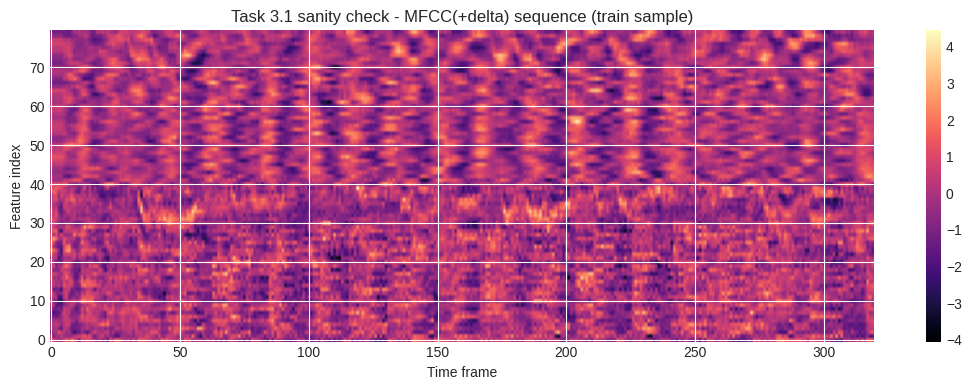

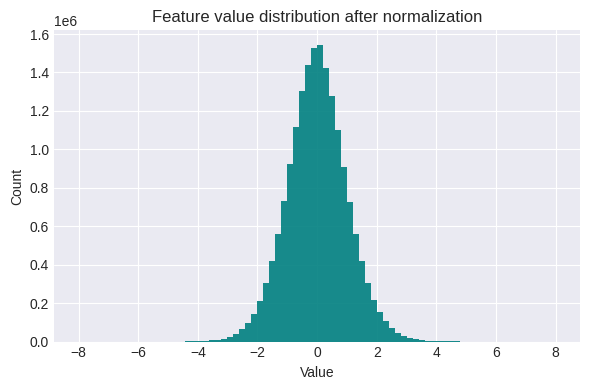

feature min/max after norm: -8.030 / 8.017


In [128]:
# quick feature visuals for report + sanity checks
sample_idx = 3

plt.figure(figsize=(11, 4))
plt.imshow(train_x[sample_idx].T, aspect='auto', origin='lower', cmap='magma')
plt.colorbar()
plt.title('Task 3.1 sanity check - MFCC(+delta) sequence (train sample)')
plt.xlabel('Time frame')
plt.ylabel('Feature index')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(train_x.reshape(-1), bins=80, alpha=0.9, color='teal')
plt.title('Feature value distribution after normalization')
plt.xlabel('Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f'feature min/max after norm: {train_x.min():.3f} / {train_x.max():.3f}')

### Sequence Dataset + DataLoader for Net5
trying a small train-time mask augmentation so the LSTM does not just memorize patterns.

In [129]:
class GTZANAudioSequenceDataset(Dataset):
    def __init__(self, x, y, augment=False):
        self.x = x
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        seq = self.x[idx].copy()  # (time, feature)
        label = int(self.y[idx])

        if self.augment:
            # TODO: maybe tune these mask ranges later
            if np.random.rand() < 0.55:
                t = np.random.randint(8, 45)
                t0 = np.random.randint(0, max(1, seq.shape[0] - t))
                seq[t0:t0 + t, :] = 0.0

            if np.random.rand() < 0.45:
                f = np.random.randint(2, 10)
                f0 = np.random.randint(0, max(1, seq.shape[1] - f))
                seq[:, f0:f0 + f] = 0.0

            if np.random.rand() < 0.35:
                seq += np.random.normal(0, 0.01, size=seq.shape).astype(np.float32)

        return torch.tensor(seq, dtype=torch.float32), label


SEQ_BATCH = 24  # tried 32 first, but this is a bit safer for LSTM memory
seq_train_ds = GTZANAudioSequenceDataset(train_x, train_y, augment=True)
seq_val_ds = GTZANAudioSequenceDataset(val_x, val_y, augment=False)
seq_test_ds = GTZANAudioSequenceDataset(test_x, test_y, augment=False)

seq_train_loader = DataLoader(seq_train_ds, batch_size=SEQ_BATCH, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY)
seq_val_loader = DataLoader(seq_val_ds, batch_size=SEQ_BATCH, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)
seq_test_loader = DataLoader(seq_test_ds, batch_size=SEQ_BATCH, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)

xb, yb = next(iter(seq_train_loader))
print(f'batch x shape: {xb.shape}, batch y shape: {yb.shape}')
assert xb.ndim == 3 and xb.shape[1] == MAX_FRAMES_NET5, f'unexpected seq batch shape: {xb.shape}'

batch x shape: torch.Size([24, 320, 80]), batch y shape: torch.Size([24])


## Task 3.2 - Net5 (LSTM)
not totally sure about best hidden size yet, starting with biLSTM + pooled output and tuning from there step by step.

In [130]:
class Net5LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=192, num_layers=2, bidirectional=True, dropout=0.35, num_classes=10):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )

        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc1 = nn.Linear(out_dim * 2, 256)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, num_classes)
        self._printed_shapes = False

    def forward(self, x):
        # x is (batch, time, features)
        if not self._printed_shapes:
            print(f'Net5 forward input shape: {x.shape}')  # debug

        x = self.input_norm(x)
        out, _ = self.lstm(x)

        if not self._printed_shapes:
            print(f'Net5 lstm out shape: {out.shape}')
            self._printed_shapes = True

        avg_pool = out.mean(dim=1)
        max_pool, _ = out.max(dim=1)
        z = torch.cat([avg_pool, max_pool], dim=1)
        z = self.drop(F.relu(self.fc1(z)))
        return self.fc2(z)


def run_one_epoch_seq(model, loader, crit, opt=None, grad_clip=1.0):
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for seq, labels in loader:
        seq = seq.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(seq)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    loss_epoch = running_loss / len(loader)
    acc_epoch = 100.0 * running_correct / running_total
    return loss_epoch, acc_epoch


def train_net5(model, train_loader, val_loader, crit, opt, scheduler=None, max_epochs=35, min_epochs=12, patience=7, grad_clip=1.0):
    # Traning loop (typo lol)
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_state = None
    best_val_loss = float('inf')
    best_val_acc = 0.0
    no_improve = 0

    for ep in range(1, max_epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = run_one_epoch_seq(model, train_loader, crit, opt=opt, grad_clip=grad_clip)
        with torch.no_grad():
            va_loss, va_acc = run_one_epoch_seq(model, val_loader, crit, opt=None)

        if scheduler is not None:
            scheduler.step(va_loss)

        current_lr = opt.param_groups[0]['lr']
        hist['train_loss'].append(tr_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_loss'].append(va_loss)
        hist['val_acc'].append(va_acc)
        hist['lr'].append(current_lr)

        if va_loss < (best_val_loss - 1e-4):
            best_val_loss = va_loss
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        dt = time.time() - t0
        print(f'Epoch {ep:03d} | tr_loss {tr_loss:.4f} | tr_acc {tr_acc:.2f}% | va_loss {va_loss:.4f} | va_acc {va_acc:.2f}% | lr {current_lr:.6f} | {dt:.1f}s')

        if ep >= min_epochs and no_improve >= patience:
            print(f'early stopping at epoch {ep} (no val loss improvement for {patience} epochs)')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return hist, best_val_acc, best_val_loss

Training samples: 699, Val: 201, Test: 100
loading saved Net5 checkpoint...
loaded checkpoint successfully (best val acc recorded: 52.24%)


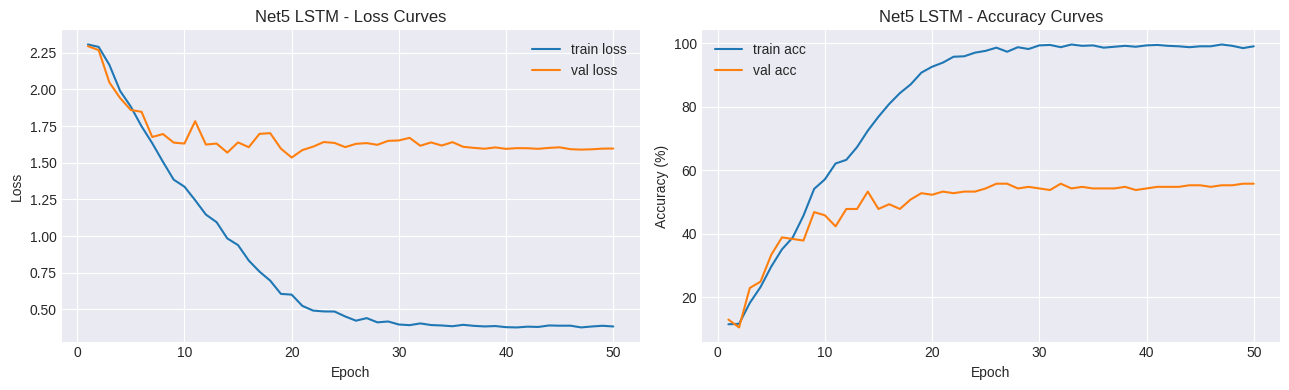

Net5 forward input shape: torch.Size([24, 320, 80])
Net5 lstm out shape: torch.Size([24, 320, 384])
Net5 Test Loss: 1.4615
Net5 Test Accuracy: 54.0000%


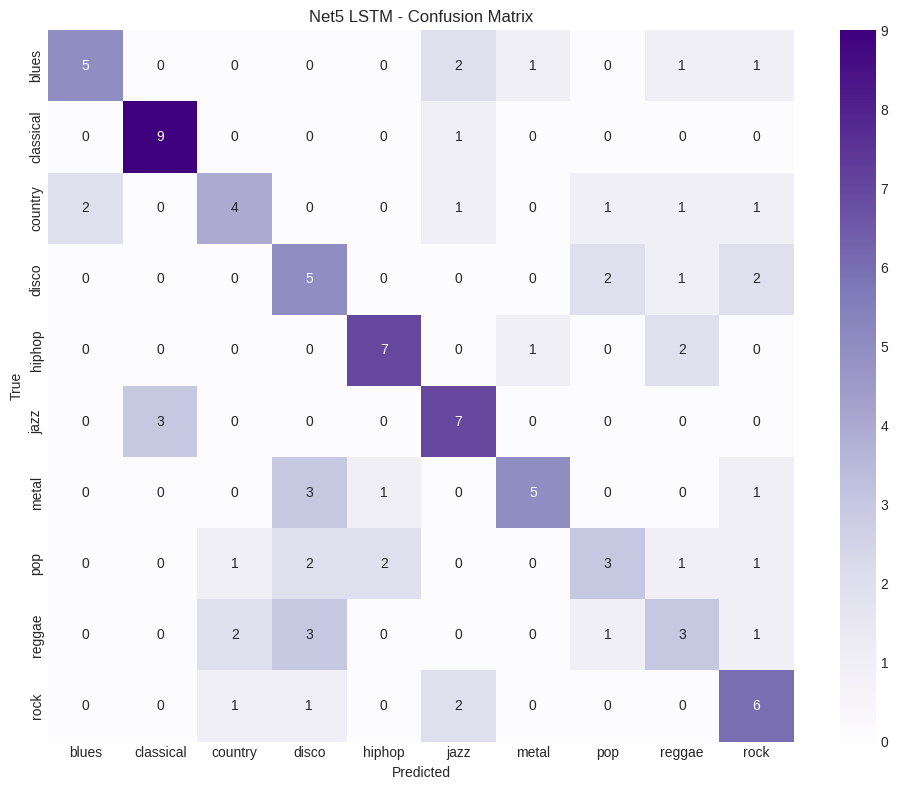

              precision  recall  f1-score  support
blues            0.7143    0.50    0.5882    10.00
classical        0.7500    0.90    0.8182    10.00
country          0.5000    0.40    0.4444    10.00
disco            0.3571    0.50    0.4167    10.00
hiphop           0.7000    0.70    0.7000    10.00
jazz             0.5385    0.70    0.6087    10.00
metal            0.7143    0.50    0.5882    10.00
pop              0.4286    0.30    0.3529    10.00
reggae           0.3333    0.30    0.3158    10.00
rock             0.4615    0.60    0.5217    10.00
accuracy         0.5400    0.54    0.5400     0.54
macro avg        0.5498    0.54    0.5355   100.00
weighted avg     0.5498    0.54    0.5355   100.00

            Model  Test Accuracy (%)  Test Loss  Best Val Accuracy (%)  Epochs Trained  Best Image Model Acc (%)  Gap vs Best Image (pp)
Net5 (LSTM audio)               54.0   1.461535              52.238806              50                      69.0                   -15.0

Net5 repor

In [131]:
# Net5 training config - increased epoch budget since this model trains quickly on this machine
NET5_MAX_EPOCHS = 120
NET5_MIN_EPOCHS = 50
NET5_PATIENCE = 12
NET5_FORCE_RETRAIN = False

net5_save_path = MODEL_DIR / 'net5_trained.pth'
net5_hist_path = RESULTS_DIR / 'metrics' / 'net5_history.csv'
net5_report_path = RESULTS_DIR / 'metrics' / 'net5_classification_report.csv'
net5_summary_path = RESULTS_DIR / 'metrics' / 'net5_summary.csv'
net5_obs_path = RESULTS_DIR / 'metrics' / 'net5_observations_for_report.txt'

net5 = Net5LSTM(
    input_dim=NET5_FEATURE_DIM,
    hidden_dim=192,
    num_layers=2,
    bidirectional=True,
    dropout=0.35,
    num_classes=len(GENRES),
).to(device)

crit5 = nn.CrossEntropyLoss(label_smoothing=0.05)
opt5 = torch.optim.AdamW(net5.parameters(), lr=8e-4, weight_decay=1e-4)
sched5 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt5, mode='min', factor=0.5, patience=3, min_lr=1e-5)

# tried plain Adam before too
# opt5 = torch.optim.Adam(net5.parameters(), lr=0.001)

history_net5 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc_net5 = 0.0
best_val_loss_net5 = float('inf')

print(f'Training samples: {len(seq_train_ds)}, Val: {len(seq_val_ds)}, Test: {len(seq_test_ds)}')

should_train_net5 = True
if net5_save_path.exists() and not NET5_FORCE_RETRAIN:
    print('loading saved Net5 checkpoint...')
    ck5 = torch.load(net5_save_path, map_location=device)

    candidate_state = ck5
    loaded_budget = None

    if isinstance(ck5, dict) and 'model_state_dict' in ck5:
        candidate_state = ck5['model_state_dict']
        history_net5 = ck5.get('history', history_net5)
        best_val_acc_net5 = ck5.get('best_val_acc', best_val_acc_net5)
        best_val_loss_net5 = ck5.get('best_val_loss', best_val_loss_net5)
        loaded_budget = ck5.get('config', {}).get('max_epochs', None)

    try:
        net5.load_state_dict(candidate_state)
        should_train_net5 = False
        print(f'loaded checkpoint successfully (best val acc recorded: {best_val_acc_net5:.2f}%)')

        if loaded_budget is not None and loaded_budget < NET5_MAX_EPOCHS:
            print(
                f'checkpoint was trained with max_epochs={loaded_budget}, '
                f'retraining with updated max_epochs={NET5_MAX_EPOCHS}'
            )
            should_train_net5 = True
    except RuntimeError as e:
        print(f'old checkpoint shape mismatch -> retrain needed: {e}')
        should_train_net5 = True

if should_train_net5:
    print('training Net5 now... this might take some time')
    history_net5, best_val_acc_net5, best_val_loss_net5 = train_net5(
        net5,
        seq_train_loader,
        seq_val_loader,
        crit5,
        opt5,
        scheduler=sched5,
        max_epochs=NET5_MAX_EPOCHS,
        min_epochs=NET5_MIN_EPOCHS,
        patience=NET5_PATIENCE,
        grad_clip=1.0,
    )

    torch.save(
        {
            'model_state_dict': net5.state_dict(),
            'history': history_net5,
            'best_val_acc': best_val_acc_net5,
            'best_val_loss': best_val_loss_net5,
            'config': {
                'max_epochs': NET5_MAX_EPOCHS,
                'min_epochs': NET5_MIN_EPOCHS,
                'patience': NET5_PATIENCE,
                'input_dim': NET5_FEATURE_DIM,
                'hidden_dim': 192,
                'layers': 2,
                'bidirectional': True,
            },
        },
        net5_save_path,
    )
    print(f'Net5 saved to {net5_save_path}')

# plot training curves
if len(history_net5.get('train_loss', [])) > 0:
    ep5 = np.arange(1, len(history_net5['train_loss']) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    ax[0].plot(ep5, history_net5['train_loss'], label='train loss')
    ax[0].plot(ep5, history_net5['val_loss'], label='val loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Net5 LSTM - Loss Curves')
    ax[0].legend()

    ax[1].plot(ep5, history_net5['train_acc'], label='train acc')
    ax[1].plot(ep5, history_net5['val_acc'], label='val acc')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy (%)')
    ax[1].set_title('Net5 LSTM - Accuracy Curves')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('history was empty (likely loading very old checkpoint format)')

# test evaluation
with torch.no_grad():
    net5_test_loss, net5_test_acc = run_one_epoch_seq(net5, seq_test_loader, crit5, opt=None)

print(f'Net5 Test Loss: {net5_test_loss:.4f}')
print(f'Net5 Test Accuracy: {net5_test_acc:.4f}%')

# confusion matrix + classification report
net5.eval()
all_preds5 = []
all_labels5 = []

with torch.no_grad():
    for seq, labels in seq_test_loader:
        seq = seq.to(device)
        logits5 = net5(seq)
        preds5 = logits5.argmax(dim=1).cpu().numpy()
        all_preds5.extend(preds5)
        all_labels5.extend(labels.numpy())

cm5 = confusion_matrix(all_labels5, all_preds5)

plt.figure(figsize=(10, 8))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Purples', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net5 LSTM - Confusion Matrix')
plt.tight_layout()
plt.show()

report5 = classification_report(all_labels5, all_preds5, target_names=GENRES, output_dict=True, zero_division=0)
report5_df = pd.DataFrame(report5).T
print(report5_df.round(4))

# save outputs for report section
pd.DataFrame(history_net5).to_csv(net5_hist_path, index=False)
report5_df.to_csv(net5_report_path)

available_image_scores = []
for var_name in ['test_acc', 'net2_test_acc', 'net3_test_acc', 'net4_test_acc']:
    if var_name in globals():
        available_image_scores.append(float(globals()[var_name]))

if len(available_image_scores) > 0:
    best_image_acc = max(available_image_scores)
    acc_gap_vs_best_image = net5_test_acc - best_image_acc
else:
    best_image_acc = np.nan
    acc_gap_vs_best_image = np.nan
    print('Net1-4 test acc variables not found, so image-vs-audio gap is set to NaN for now')

net5_summary_df = pd.DataFrame(
    {
        'Model': ['Net5 (LSTM audio)'],
        'Test Accuracy (%)': [net5_test_acc],
        'Test Loss': [net5_test_loss],
        'Best Val Accuracy (%)': [best_val_acc_net5],
        'Epochs Trained': [len(history_net5.get('train_loss', []))],
        'Best Image Model Acc (%)': [best_image_acc],
        'Gap vs Best Image (pp)': [acc_gap_vs_best_image],
    }
)
net5_summary_df.to_csv(net5_summary_path, index=False)
print('\n' + net5_summary_df.to_string(index=False))

# top confusion pairs (off-diagonal)
cm5_no_diag = cm5.copy()
np.fill_diagonal(cm5_no_diag, 0)
flat_idx = np.dstack(np.unravel_index(np.argsort(cm5_no_diag.ravel())[::-1], cm5_no_diag.shape))[0]

confusion_pairs = []
for r, c in flat_idx:
    count = int(cm5_no_diag[r, c])
    if count <= 0:
        break
    confusion_pairs.append(f'{GENRES[r]} -> {GENRES[c]} ({count})')
    if len(confusion_pairs) == 5:
        break

gap_text = f'{acc_gap_vs_best_image:+.2f} percentage points.' if not np.isnan(acc_gap_vs_best_image) else 'not computed (run Net1-4 evaluation first).'

obs_lines = [
    'Net5 report observations (can reuse in report discussion):',
    f'1. Feature choice: MFCC (+delta) with input shape ({MAX_FRAMES_NET5}, {NET5_FEATURE_DIM}) per track.',
    f'2. Training capped at {NET5_MAX_EPOCHS} epochs with early stopping (patience={NET5_PATIENCE}) for practical runtime.',
    f'3. Best validation accuracy: {best_val_acc_net5:.2f}%',
    f'4. Final test accuracy: {net5_test_acc:.2f}%',
    f'5. Gap vs best image-based model (Net1-4): {gap_text}',
    f'6. Top confusion pairs: {"; ".join(confusion_pairs) if len(confusion_pairs) > 0 else "none"}',
]

print('\n' + '\n'.join(obs_lines))

with open(net5_obs_path, 'w') as f:
    f.write('\n'.join(obs_lines))

print(f'\nSaved: {net5_hist_path}')
print(f'Saved: {net5_report_path}')
print(f'Saved: {net5_summary_path}')
print(f'Saved: {net5_obs_path}')

## Task 3.3 - Model 6 Part A (GAN for augmentation)
trying a conditional GAN here to make extra audio feature sequences for each genre.
this part was kinda tricky in lab so doing it step by step and checking shapes a lot.

In [132]:
# needed this import only for GAN section
import math
from collections import Counter

if 'train_x' not in globals() or 'train_y' not in globals():
    raise RuntimeError('run Task 3.1 first (cache + sequence prep) before Task 3.3')

GAN_FORCE_RETRAIN = False
GAN_EPOCHS = 60
GAN_BATCH = 48
GAN_NOISE_DIM = 128
GAN_LABEL_EMB = 16
GAN_LR = 2e-4
GAN_BETA1 = 0.5
GAN_BETA2 = 0.999

# TODO: maybe test bigger noise dim (160?) if generator collapses
gan_ckpt_path = MODEL_DIR / 'net6_gan_generator.pth'
gan_synth_path = RESULTS_DIR / 'metrics' / 'net6_gan_synth_v1.npz'
gan_hist_path = RESULTS_DIR / 'metrics' / 'net6_gan_history.csv'

GAN_SCALE = float(np.max(np.abs(train_x)))
if GAN_SCALE < 1e-6:
    GAN_SCALE = 1.0

train_x_scaled = np.clip(train_x / GAN_SCALE, -1.0, 1.0).astype(np.float32)
print(f'GAN scale factor: {GAN_SCALE:.4f} | scaled train range: [{train_x_scaled.min():.3f}, {train_x_scaled.max():.3f}]')


class GANTrainDataset(Dataset):
    def __init__(self, x_scaled, y):
        self.x = x_scaled
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Conv1D expects channel-first (features, time)
        seq_cf = self.x[idx].T
        label = int(self.y[idx])
        return torch.tensor(seq_cf, dtype=torch.float32), label


class AudioCondGenerator(nn.Module):
    def __init__(self, z_dim=128, num_classes=10, label_emb=16, out_channels=80):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, label_emb)
        self.fc = nn.Linear(z_dim + label_emb, 512 * 40)

        self.deconv1 = nn.ConvTranspose1d(512, 256, kernel_size=4, stride=2, padding=1)  # 40 -> 80
        self.bn1 = nn.BatchNorm1d(256)
        self.deconv2 = nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1)  # 80 -> 160
        self.bn2 = nn.BatchNorm1d(128)
        self.deconv3 = nn.ConvTranspose1d(128, out_channels, kernel_size=4, stride=2, padding=1)  # 160 -> 320

        self._printed = False

    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), 512, 40)

        x = F.relu(self.bn1(self.deconv1(x)))
        x = F.relu(self.bn2(self.deconv2(x)))
        x = torch.tanh(self.deconv3(x))

        if not self._printed:
            print(f'G output shape debug: {x.shape}')
            self._printed = True

        return x


class AudioCondDiscriminator(nn.Module):
    def __init__(self, in_channels=80, num_classes=10, label_emb=16):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, label_emb)

        self.conv1 = nn.Conv1d(in_channels + label_emb, 128, kernel_size=5, stride=2, padding=2)  # 320 -> 160
        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2)  # 160 -> 80
        self.bn2 = nn.BatchNorm1d(256)
        self.conv3 = nn.Conv1d(256, 512, kernel_size=5, stride=2, padding=2)  # 80 -> 40
        self.bn3 = nn.BatchNorm1d(512)

        self.fc = nn.Linear(512 * 40, 1)
        self._printed = False

    def forward(self, x, labels):
        # x is (batch, channels=80, time=320)
        c = self.label_emb(labels)
        c_map = c.unsqueeze(-1).expand(-1, -1, x.size(-1))
        h = torch.cat([x, c_map], dim=1)

        h = F.leaky_relu(self.conv1(h), 0.2)
        h = F.leaky_relu(self.bn2(self.conv2(h)), 0.2)
        h = F.leaky_relu(self.bn3(self.conv3(h)), 0.2)
        h = h.flatten(1)
        out = self.fc(h)

        if not self._printed:
            print(f'D input shape debug: {x.shape}, logits shape: {out.shape}')
            self._printed = True

        return out


def train_cond_gan(G, D, loader, epochs=60, z_dim=128, lr=2e-4):
    bce = nn.BCEWithLogitsLoss()
    opt_g = torch.optim.Adam(G.parameters(), lr=lr, betas=(GAN_BETA1, GAN_BETA2))
    opt_d = torch.optim.Adam(D.parameters(), lr=lr, betas=(GAN_BETA1, GAN_BETA2))

    hist = {'epoch': [], 'd_loss': [], 'g_loss': [], 'd_real_score': [], 'd_fake_score': []}

    for ep in range(1, epochs + 1):
        t0 = time.time()

        d_loss_sum = 0.0
        g_loss_sum = 0.0
        d_real_sum = 0.0
        d_fake_sum = 0.0

        for real_cf, labels in loader:
            real_cf = real_cf.to(device)
            labels = labels.to(device)
            bs = real_cf.size(0)

            # train D
            opt_d.zero_grad()
            z = torch.randn(bs, z_dim, device=device)
            fake_cf = G(z, labels)

            # add a bit of instance noise early in training, seemed to help in lab
            warm_eps = max(1, int(0.35 * epochs))
            if ep <= warm_eps:
                noise_std = 0.06 * (1.0 - ep / warm_eps)
                real_in = real_cf + noise_std * torch.randn_like(real_cf)
                fake_in = fake_cf.detach() + noise_std * torch.randn_like(fake_cf)
            else:
                real_in = real_cf
                fake_in = fake_cf.detach()

            real_logits = D(real_in, labels)
            fake_logits = D(fake_in, labels)

            real_targets = torch.empty_like(real_logits).uniform_(0.85, 1.0)
            fake_targets = torch.empty_like(fake_logits).uniform_(0.0, 0.15)

            loss_d_real = bce(real_logits, real_targets)
            loss_d_fake = bce(fake_logits, fake_targets)
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=5.0)
            opt_d.step()

            # train G
            opt_g.zero_grad()
            z2 = torch.randn(bs, z_dim, device=device)
            labels2 = labels[torch.randperm(bs)]  # shuffle labels a bit for variety
            fake_for_g = G(z2, labels2)
            gen_logits = D(fake_for_g, labels2)
            gen_targets = torch.empty_like(gen_logits).uniform_(0.85, 1.0)

            adv_loss = bce(gen_logits, gen_targets)

            # tiny stat matching term so generated MFCCs don't go too wild
            real_m = real_cf.mean(dim=(1, 2)).detach()
            fake_m = fake_for_g.mean(dim=(1, 2))
            real_s = real_cf.std(dim=(1, 2)).detach()
            fake_s = fake_for_g.std(dim=(1, 2))
            stat_loss = F.l1_loss(fake_m, real_m) + F.l1_loss(fake_s, real_s)

            loss_g = adv_loss + 0.15 * stat_loss
            loss_g.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=5.0)
            opt_g.step()

            d_loss_sum += loss_d.item()
            g_loss_sum += loss_g.item()
            d_real_sum += torch.sigmoid(real_logits).mean().item()
            d_fake_sum += torch.sigmoid(fake_logits).mean().item()

        n_batches = len(loader)
        hist['epoch'].append(ep)
        hist['d_loss'].append(d_loss_sum / n_batches)
        hist['g_loss'].append(g_loss_sum / n_batches)
        hist['d_real_score'].append(d_real_sum / n_batches)
        hist['d_fake_score'].append(d_fake_sum / n_batches)

        if ep == 1 or ep % 5 == 0:
            dt = time.time() - t0
            print(
                f'GAN Ep {ep:03d} | D {hist["d_loss"][-1]:.4f} | G {hist["g_loss"][-1]:.4f} '
                f'| D(real) {hist["d_real_score"][-1]:.3f} | D(fake) {hist["d_fake_score"][-1]:.3f} | {dt:.1f}s'
            )

    return hist


@torch.no_grad()
def generate_balanced_synth(G, D, class_counts, oversample=2.0, z_dim=128):
    G.eval()
    D.eval()

    synth_x_list = []
    synth_y_list = []

    for cls_idx, n_need in sorted(class_counts.items()):
        n_pool = max(n_need, int(math.ceil(n_need * oversample)))
        made = 0
        cand_cf = []
        cand_score = []

        while made < n_pool:
            bs = min(64, n_pool - made)
            z = torch.randn(bs, z_dim, device=device)
            labels = torch.full((bs,), cls_idx, dtype=torch.long, device=device)
            fake_cf = G(z, labels)
            logits = D(fake_cf, labels).squeeze(1)
            probs = torch.sigmoid(logits)

            cand_cf.append(fake_cf.cpu())
            cand_score.append(probs.cpu())
            made += bs

        cand_cf = torch.cat(cand_cf, dim=0)
        cand_score = torch.cat(cand_score, dim=0)

        keep_idx = torch.topk(cand_score, k=n_need, largest=True).indices
        best_cf = cand_cf[keep_idx]
        best_tf = best_cf.numpy().transpose(0, 2, 1).astype(np.float32)

        synth_x_list.append(best_tf)
        synth_y_list.append(np.full(n_need, cls_idx, dtype=np.int64))

        print(f'GAN synth {GENRES[cls_idx]}: generated {n_pool}, kept top {n_need}')

    synth_x_scaled = np.concatenate(synth_x_list, axis=0)
    synth_y = np.concatenate(synth_y_list, axis=0)

    # shuffle to avoid class blocks
    p = np.random.permutation(len(synth_y))
    synth_x_scaled = synth_x_scaled[p]
    synth_y = synth_y[p]

    # map back from [-1, 1] to original feature scale used by Net5
    synth_x = (synth_x_scaled * GAN_SCALE).astype(np.float32)
    return synth_x, synth_y

GAN scale factor: 8.0296 | scaled train range: [-1.000, 0.998]


training conditional GAN now... this can be noisy at first


G output shape debug: torch.Size([48, 80, 320])
D input shape debug: torch.Size([48, 80, 320]), logits shape: torch.Size([48, 1])
GAN Ep 001 | D 1.3286 | G 0.9291 | D(real) 0.544 | D(fake) 0.468 | 0.2s
GAN Ep 005 | D 0.9832 | G 1.8027 | D(real) 0.691 | D(fake) 0.292 | 0.2s
GAN Ep 010 | D 1.4086 | G 0.9554 | D(real) 0.509 | D(fake) 0.475 | 0.2s
GAN Ep 015 | D 1.3235 | G 0.8885 | D(real) 0.550 | D(fake) 0.473 | 0.1s
GAN Ep 020 | D 1.3359 | G 0.8773 | D(real) 0.538 | D(fake) 0.473 | 0.1s
GAN Ep 025 | D 1.2352 | G 0.9797 | D(real) 0.570 | D(fake) 0.437 | 0.2s
GAN Ep 030 | D 1.2075 | G 1.2089 | D(real) 0.562 | D(fake) 0.397 | 0.2s
GAN Ep 035 | D 0.9808 | G 1.5215 | D(real) 0.680 | D(fake) 0.340 | 0.2s
GAN Ep 040 | D 0.9591 | G 1.6997 | D(real) 0.642 | D(fake) 0.289 | 0.2s
GAN Ep 045 | D 0.9260 | G 1.7959 | D(real) 0.676 | D(fake) 0.289 | 0.1s
GAN Ep 050 | D 0.9260 | G 1.6754 | D(real) 0.677 | D(fake) 0.292 | 0.1s
GAN Ep 055 | D 0.7957 | G 1.9097 | D(real) 0.744 | D(fake) 0.247 | 0.2s
GAN Ep

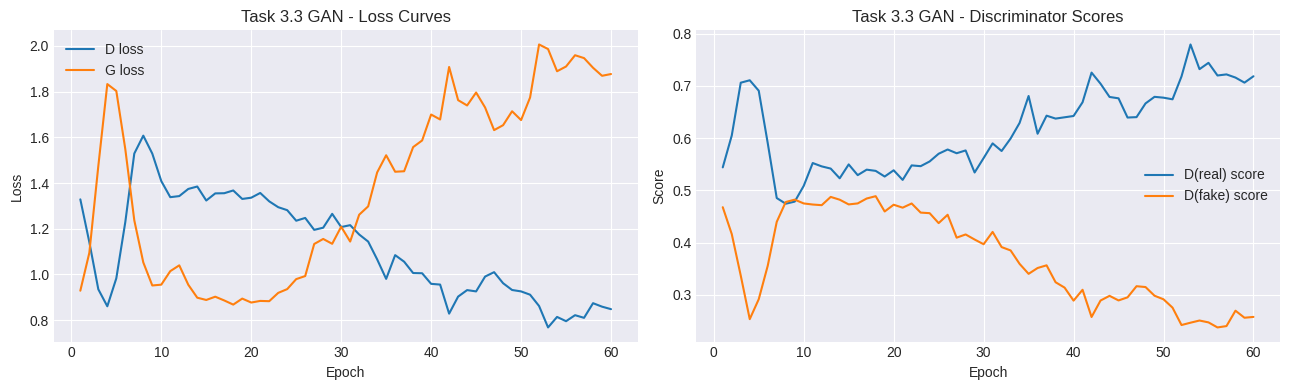

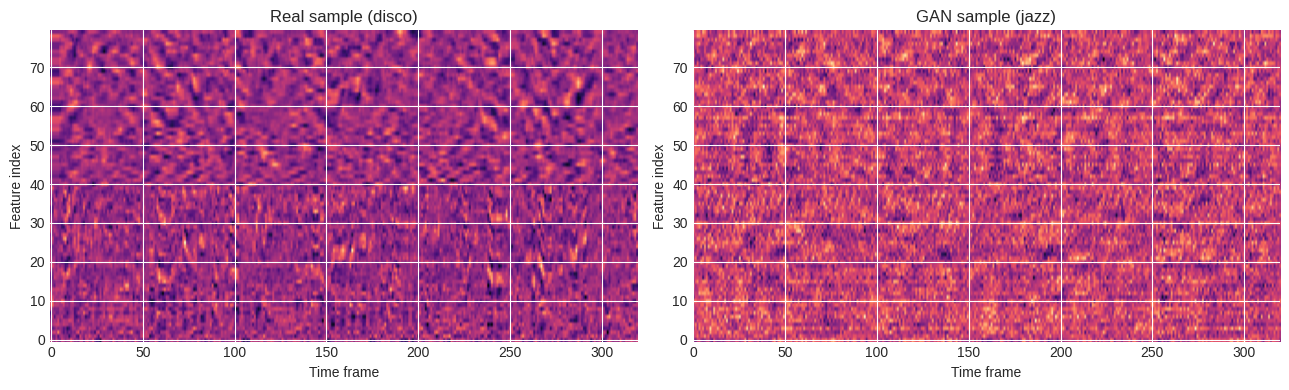

Saved GAN history CSV: /home/jarvis/lakshya/Music Project/results/metrics/net6_gan_history.csv


In [133]:
# train/load GAN and generate class-balanced synthetic sequences

gan_ds = GANTrainDataset(train_x_scaled, train_y)
gan_loader = DataLoader(gan_ds, batch_size=GAN_BATCH, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY, drop_last=True)

G = AudioCondGenerator(
    z_dim=GAN_NOISE_DIM,
    num_classes=len(GENRES),
    label_emb=GAN_LABEL_EMB,
    out_channels=NET5_FEATURE_DIM,
).to(device)

D = AudioCondDiscriminator(
    in_channels=NET5_FEATURE_DIM,
    num_classes=len(GENRES),
    label_emb=GAN_LABEL_EMB,
).to(device)

need_train_gan = GAN_FORCE_RETRAIN or (not gan_ckpt_path.exists()) or (not gan_synth_path.exists())
gan_history_df = None

if not need_train_gan:
    try:
        print('loading saved GAN + synthetic set...')
        gan_ck = torch.load(gan_ckpt_path, map_location=device)
        G.load_state_dict(gan_ck['generator_state_dict'])

        if 'discriminator_state_dict' in gan_ck:
            D.load_state_dict(gan_ck['discriminator_state_dict'])

        old_epochs = gan_ck.get('config', {}).get('gan_epochs', 0)
        if old_epochs < GAN_EPOCHS:
            print(f'saved GAN epochs={old_epochs}, but current setting is {GAN_EPOCHS} -> retraining')
            need_train_gan = True
        else:
            synth_pack = np.load(gan_synth_path, allow_pickle=True)
            synth_x = synth_pack['synth_x'].astype(np.float32)
            synth_y = synth_pack['synth_y'].astype(np.int64)
            print(f'loaded synth data: x {synth_x.shape}, y {synth_y.shape}')

            if gan_hist_path.exists():
                gan_history_df = pd.read_csv(gan_hist_path)
    except Exception as e:
        print(f'GAN load failed -> retraining ({e})')
        need_train_gan = True

if need_train_gan:
    print('training conditional GAN now... this can be noisy at first')
    gan_history = train_cond_gan(G, D, gan_loader, epochs=GAN_EPOCHS, z_dim=GAN_NOISE_DIM, lr=GAN_LR)
    gan_history_df = pd.DataFrame(gan_history)

    class_counts = dict(sorted(Counter(train_y).items()))
    print('class counts used for generation:', class_counts)

    synth_x, synth_y = generate_balanced_synth(
        G,
        D,
        class_counts,
        oversample=2.0,
        z_dim=GAN_NOISE_DIM,
    )

    torch.save(
        {
            'generator_state_dict': G.state_dict(),
            'discriminator_state_dict': D.state_dict(),
            'config': {
                'gan_epochs': GAN_EPOCHS,
                'noise_dim': GAN_NOISE_DIM,
                'batch_size': GAN_BATCH,
                'label_emb': GAN_LABEL_EMB,
                'lr': GAN_LR,
                'scale': GAN_SCALE,
            },
        },
        gan_ckpt_path,
    )

    np.savez_compressed(
        gan_synth_path,
        synth_x=synth_x,
        synth_y=synth_y,
        scale=np.array([GAN_SCALE], dtype=np.float32),
        noise_dim=np.array([GAN_NOISE_DIM], dtype=np.int64),
        gan_epochs=np.array([GAN_EPOCHS], dtype=np.int64),
    )

    gan_history_df.to_csv(gan_hist_path, index=False)
    print(f'GAN checkpoint saved: {gan_ckpt_path}')
    print(f'GAN synth dataset saved: {gan_synth_path}')

print(f'synth_x shape: {synth_x.shape}, synth_y shape: {synth_y.shape}')
assert synth_x.shape[1:] == (MAX_FRAMES_NET5, NET5_FEATURE_DIM), f'bad synth shape: {synth_x.shape}'

# target for part A says same number of synthetic samples as training data
assert len(synth_x) == len(train_x), f'synth count {len(synth_x)} != train count {len(train_x)}'
print('synth label distribution:', dict(sorted(Counter(synth_y).items())))

if gan_history_df is not None and len(gan_history_df) > 0:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    ax[0].plot(gan_history_df['epoch'], gan_history_df['d_loss'], label='D loss')
    ax[0].plot(gan_history_df['epoch'], gan_history_df['g_loss'], label='G loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Task 3.3 GAN - Loss Curves')
    ax[0].legend()

    ax[1].plot(gan_history_df['epoch'], gan_history_df['d_real_score'], label='D(real) score')
    ax[1].plot(gan_history_df['epoch'], gan_history_df['d_fake_score'], label='D(fake) score')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Score')
    ax[1].set_title('Task 3.3 GAN - Discriminator Scores')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

# visual check: real vs generated MFCC(+delta)
real_idx = 2
fake_idx = 2

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].imshow(train_x[real_idx].T, aspect='auto', origin='lower', cmap='magma')
ax[0].set_title(f'Real sample ({GENRES[int(train_y[real_idx])]})')
ax[0].set_xlabel('Time frame')
ax[0].set_ylabel('Feature index')

ax[1].imshow(synth_x[fake_idx].T, aspect='auto', origin='lower', cmap='magma')
ax[1].set_title(f'GAN sample ({GENRES[int(synth_y[fake_idx])]})')
ax[1].set_xlabel('Time frame')
ax[1].set_ylabel('Feature index')

plt.tight_layout()
plt.show()

print(f'Saved GAN history CSV: {gan_hist_path}')

## Task 3.4 - Model 6 Part B (LSTM + GAN-augmented data)
using the same LSTM idea as Net5, but now training with original + GAN-generated sequences.
hopefully this gives better generalization, but let's test it properly.

In [134]:
class Net6AugSequenceDataset(Dataset):
    def __init__(self, x, y, is_synth, augment=False):
        self.x = x
        self.y = y
        self.is_synth = is_synth
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        seq = self.x[idx].copy()
        label = int(self.y[idx])
        synth_flag = int(self.is_synth[idx])

        if self.augment:
            # similar to Net5 augmentation, but synth samples get slightly different noise
            if np.random.rand() < 0.50:
                t = np.random.randint(6, 36)
                t0 = np.random.randint(0, max(1, seq.shape[0] - t))
                seq[t0:t0 + t, :] = 0.0

            if np.random.rand() < 0.40:
                f = np.random.randint(2, 8)
                f0 = np.random.randint(0, max(1, seq.shape[1] - f))
                seq[:, f0:f0 + f] = 0.0

            if synth_flag == 1 and np.random.rand() < 0.45:
                seq += np.random.normal(0, 0.008, size=seq.shape).astype(np.float32)
            elif synth_flag == 0 and np.random.rand() < 0.25:
                seq += np.random.normal(0, 0.005, size=seq.shape).astype(np.float32)

        return torch.tensor(seq, dtype=torch.float32), label, synth_flag


def run_one_epoch_seq_aug(model, loader, crit_per_sample, opt=None, grad_clip=1.0, synth_weight=0.70):
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for seq, labels, synth_flag in loader:
        seq = seq.to(device)
        labels = labels.to(device)
        synth_flag = synth_flag.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(seq)
        loss_vec = crit_per_sample(logits, labels)

        sample_w = torch.where(
            synth_flag > 0,
            torch.full_like(loss_vec, synth_weight),
            torch.ones_like(loss_vec),
        )

        loss = (loss_vec * sample_w).mean()

        if opt is not None:
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * running_correct / running_total
    return epoch_loss, epoch_acc


def train_net6(
    model,
    train_loader,
    val_loader,
    crit_train,
    crit_eval,
    opt,
    scheduler=None,
    max_epochs=90,
    min_epochs=50,
    patience=14,
    grad_clip=1.0,
    synth_weight=0.70,
):
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    best_state = None
    best_val_loss = float('inf')
    best_val_acc = 0.0
    stale = 0

    for ep in range(1, max_epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = run_one_epoch_seq_aug(
            model,
            train_loader,
            crit_train,
            opt=opt,
            grad_clip=grad_clip,
            synth_weight=synth_weight,
        )

        with torch.no_grad():
            va_loss, va_acc = run_one_epoch_seq(model, val_loader, crit_eval, opt=None)

        if scheduler is not None:
            scheduler.step(va_loss)

        current_lr = opt.param_groups[0]['lr']
        hist['train_loss'].append(tr_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_loss'].append(va_loss)
        hist['val_acc'].append(va_acc)
        hist['lr'].append(current_lr)

        if va_loss < (best_val_loss - 1e-4):
            best_val_loss = va_loss
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1

        dt = time.time() - t0
        print(
            f'Net6 Ep {ep:03d} | tr_loss {tr_loss:.4f} | tr_acc {tr_acc:.2f}% | '
            f'va_loss {va_loss:.4f} | va_acc {va_acc:.2f}% | lr {current_lr:.6f} | {dt:.1f}s'
        )

        if ep >= min_epochs and stale >= patience:
            print(f'Net6 early stopping at epoch {ep} (no val loss improvement for {patience} epochs)')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return hist, best_val_acc, best_val_loss

Net6 train set size: 1398 (real=699, synth=699)
augmented label distribution: {np.int64(0): 140, np.int64(1): 140, np.int64(2): 140, np.int64(3): 140, np.int64(4): 140, np.int64(5): 140, np.int64(6): 138, np.int64(7): 140, np.int64(8): 140, np.int64(9): 140}
initialized Net6 from in-memory Net5 weights


Net5 forward input shape: torch.Size([28, 320, 80])
Net5 lstm out shape: torch.Size([28, 320, 384])
Net6 Ep 001 | tr_loss 1.2910 | tr_acc 53.86% | va_loss 1.3502 | va_acc 52.74% | lr 0.000600 | 1.2s
Net6 Ep 002 | tr_loss 1.0403 | tr_acc 59.16% | va_loss 1.4980 | va_acc 46.27% | lr 0.000600 | 1.2s
Net6 Ep 003 | tr_loss 0.9134 | tr_acc 65.45% | va_loss 1.5715 | va_acc 50.25% | lr 0.000600 | 1.2s
Net6 Ep 004 | tr_loss 0.8458 | tr_acc 68.88% | va_loss 1.5153 | va_acc 55.22% | lr 0.000600 | 1.2s
Net6 Ep 005 | tr_loss 0.7898 | tr_acc 72.03% | va_loss 1.5163 | va_acc 52.24% | lr 0.000600 | 1.2s
Net6 Ep 006 | tr_loss 0.6871 | tr_acc 78.47% | va_loss 1.5089 | va_acc 57.71% | lr 0.000300 | 1.2s
Net6 Ep 007 | tr_loss 0.6086 | tr_acc 84.84% | va_loss 1.5141 | va_acc 56.72% | lr 0.000300 | 1.2s
Net6 Ep 008 | tr_loss 0.5617 | tr_acc 88.48% | va_loss 1.5164 | va_acc 54.23% | lr 0.000300 | 1.2s
Net6 Ep 009 | tr_loss 0.5035 | tr_acc 90.92% | va_loss 1.5406 | va_acc 56.72% | lr 0.000300 | 1.2s
Net6 Ep 0

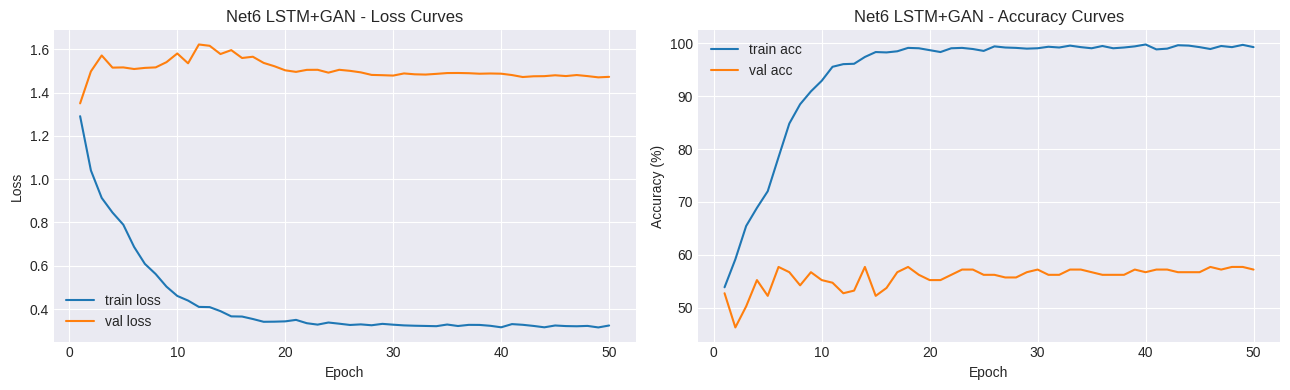

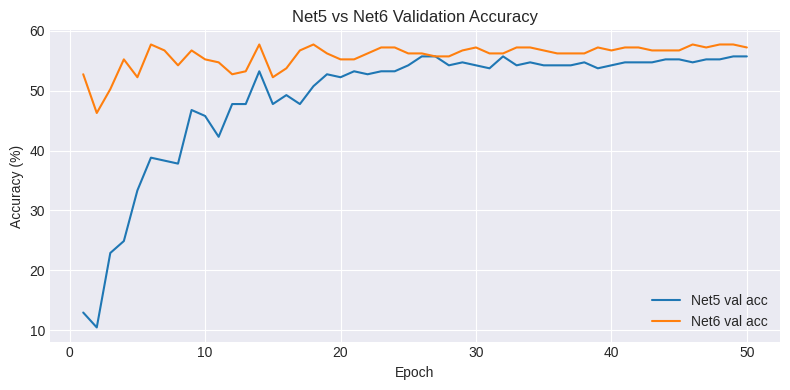

Net6 Test Loss: 1.3889
Net6 Test Accuracy: 57.0000%


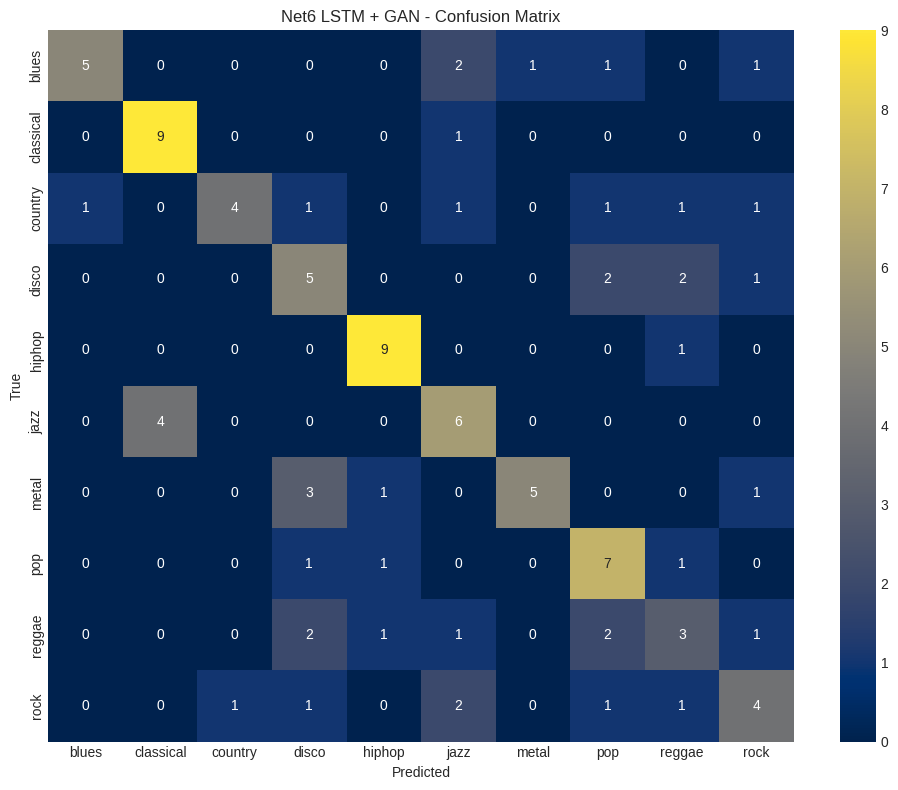

              precision  recall  f1-score  support
blues            0.8333    0.50    0.6250    10.00
classical        0.6923    0.90    0.7826    10.00
country          0.8000    0.40    0.5333    10.00
disco            0.3846    0.50    0.4348    10.00
hiphop           0.7500    0.90    0.8182    10.00
jazz             0.4615    0.60    0.5217    10.00
metal            0.8333    0.50    0.6250    10.00
pop              0.5000    0.70    0.5833    10.00
reggae           0.3333    0.30    0.3158    10.00
rock             0.4444    0.40    0.4211    10.00
accuracy         0.5700    0.57    0.5700     0.57
macro avg        0.6033    0.57    0.5661   100.00
weighted avg     0.6033    0.57    0.5661   100.00

                         Model  Test Accuracy (%)  Test Loss  Best Val Accuracy (%)  Epochs Trained  Augmented Train Samples  Synthetic Samples Used  Delta vs Net5 (pp)
Net6 (LSTM + GAN augmentation)               57.0   1.388899              52.736318              50                 

In [135]:
# Net6 training/evaluation using original + GAN-generated sequences

NET6_MAX_EPOCHS = 100
NET6_MIN_EPOCHS = 50
NET6_PATIENCE = 14
NET6_SYNTH_WEIGHT = 0.72
NET6_FORCE_RETRAIN = False
NET6_BATCH = 28

net6_save_path = MODEL_DIR / 'net6_trained.pth'
net6_hist_path = RESULTS_DIR / 'metrics' / 'net6_history.csv'
net6_report_path = RESULTS_DIR / 'metrics' / 'net6_classification_report.csv'
net6_summary_path = RESULTS_DIR / 'metrics' / 'net6_summary.csv'
net6_vs_net5_path = RESULTS_DIR / 'metrics' / 'net6_vs_net5.csv'
net6_obs_path = RESULTS_DIR / 'metrics' / 'net6_observations_for_report.txt'

# combine original + synthetic data
aug_x = np.concatenate([train_x, synth_x], axis=0).astype(np.float32)
aug_y = np.concatenate([train_y, synth_y], axis=0).astype(np.int64)
aug_is_synth = np.concatenate([
    np.zeros(len(train_x), dtype=np.int64),
    np.ones(len(synth_x), dtype=np.int64),
], axis=0)

perm = np.random.permutation(len(aug_y))
aug_x = aug_x[perm]
aug_y = aug_y[perm]
aug_is_synth = aug_is_synth[perm]

net6_train_ds = Net6AugSequenceDataset(aug_x, aug_y, aug_is_synth, augment=True)
net6_train_loader = DataLoader(net6_train_ds, batch_size=NET6_BATCH, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY)

print(f'Net6 train set size: {len(net6_train_ds)} (real={len(train_x)}, synth={len(synth_x)})')
print('augmented label distribution:', dict(sorted(Counter(aug_y).items())))

net6 = Net5LSTM(
    input_dim=NET5_FEATURE_DIM,
    hidden_dim=192,
    num_layers=2,
    bidirectional=True,
    dropout=0.35,
    num_classes=len(GENRES),
).to(device)

crit6_train = nn.CrossEntropyLoss(label_smoothing=0.05, reduction='none')
crit6_eval = nn.CrossEntropyLoss()
opt6 = torch.optim.AdamW(net6.parameters(), lr=6e-4, weight_decay=1e-4)
sched6 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt6, mode='min', factor=0.5, patience=4, min_lr=1e-5)

history_net6 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc_net6 = 0.0
best_val_loss_net6 = float('inf')

should_train_net6 = True
if net6_save_path.exists() and not NET6_FORCE_RETRAIN:
    print('loading saved Net6 checkpoint...')
    ck6 = torch.load(net6_save_path, map_location=device)

    loaded_state = ck6
    loaded_budget = None

    if isinstance(ck6, dict) and 'model_state_dict' in ck6:
        loaded_state = ck6['model_state_dict']
        history_net6 = ck6.get('history', history_net6)
        best_val_acc_net6 = ck6.get('best_val_acc', best_val_acc_net6)
        best_val_loss_net6 = ck6.get('best_val_loss', best_val_loss_net6)
        loaded_budget = ck6.get('config', {}).get('max_epochs', None)

    try:
        net6.load_state_dict(loaded_state)
        should_train_net6 = False
        print(f'loaded Net6 checkpoint (best val acc: {best_val_acc_net6:.2f}%)')

        if loaded_budget is not None and loaded_budget < NET6_MAX_EPOCHS:
            print(f'old net6 checkpoint budget={loaded_budget}, retraining with {NET6_MAX_EPOCHS}')
            should_train_net6 = True
    except RuntimeError as e:
        print(f'old Net6 checkpoint shape mismatch -> retrain ({e})')
        should_train_net6 = True

if should_train_net6:
    # warm start from Net5 usually helps a lot
    warm_started = False
    if 'net5' in globals():
        try:
            net6.load_state_dict(net5.state_dict())
            warm_started = True
            print('initialized Net6 from in-memory Net5 weights')
        except Exception as e:
            print(f'Net5 warm-start failed in-memory: {e}')

    if (not warm_started) and net5_save_path.exists():
        try:
            ck5 = torch.load(net5_save_path, map_location=device)
            base_state = ck5['model_state_dict'] if isinstance(ck5, dict) and 'model_state_dict' in ck5 else ck5
            net6.load_state_dict(base_state)
            warm_started = True
            print('initialized Net6 from saved Net5 checkpoint')
        except Exception as e:
            print(f'Net5 warm-start from file failed: {e}')

    if not warm_started:
        print('training Net6 from random init (no Net5 warm-start available)')

    history_net6, best_val_acc_net6, best_val_loss_net6 = train_net6(
        net6,
        net6_train_loader,
        seq_val_loader,
        crit6_train,
        crit6_eval,
        opt6,
        scheduler=sched6,
        max_epochs=NET6_MAX_EPOCHS,
        min_epochs=NET6_MIN_EPOCHS,
        patience=NET6_PATIENCE,
        grad_clip=1.0,
        synth_weight=NET6_SYNTH_WEIGHT,
    )

    torch.save(
        {
            'model_state_dict': net6.state_dict(),
            'history': history_net6,
            'best_val_acc': best_val_acc_net6,
            'best_val_loss': best_val_loss_net6,
            'config': {
                'max_epochs': NET6_MAX_EPOCHS,
                'min_epochs': NET6_MIN_EPOCHS,
                'patience': NET6_PATIENCE,
                'synth_weight': NET6_SYNTH_WEIGHT,
                'batch_size': NET6_BATCH,
                'input_dim': NET5_FEATURE_DIM,
                'hidden_dim': 192,
                'layers': 2,
                'bidirectional': True,
            },
        },
        net6_save_path,
    )
    print(f'Net6 checkpoint saved: {net6_save_path}')

# plot net6 curves
if len(history_net6.get('train_loss', [])) > 0:
    ep6 = np.arange(1, len(history_net6['train_loss']) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(ep6, history_net6['train_loss'], label='train loss')
    ax[0].plot(ep6, history_net6['val_loss'], label='val loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Net6 LSTM+GAN - Loss Curves')
    ax[0].legend()

    ax[1].plot(ep6, history_net6['train_acc'], label='train acc')
    ax[1].plot(ep6, history_net6['val_acc'], label='val acc')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy (%)')
    ax[1].set_title('Net6 LSTM+GAN - Accuracy Curves')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

# optional comparison curve with net5 if history is available
if 'history_net5' in globals() and len(history_net5.get('val_acc', [])) > 0 and len(history_net6.get('val_acc', [])) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(1, len(history_net5['val_acc']) + 1), history_net5['val_acc'], label='Net5 val acc')
    plt.plot(np.arange(1, len(history_net6['val_acc']) + 1), history_net6['val_acc'], label='Net6 val acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Net5 vs Net6 Validation Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

# evaluate on test set
with torch.no_grad():
    net6_test_loss, net6_test_acc = run_one_epoch_seq(net6, seq_test_loader, crit6_eval, opt=None)

print(f'Net6 Test Loss: {net6_test_loss:.4f}')
print(f'Net6 Test Accuracy: {net6_test_acc:.4f}%')

net6.eval()
all_preds6 = []
all_labels6 = []

with torch.no_grad():
    for seq, labels in seq_test_loader:
        seq = seq.to(device)
        logits6 = net6(seq)
        preds6 = logits6.argmax(dim=1).cpu().numpy()
        all_preds6.extend(preds6)
        all_labels6.extend(labels.numpy())

cm6 = confusion_matrix(all_labels6, all_preds6)

plt.figure(figsize=(10, 8))
sns.heatmap(cm6, annot=True, fmt='d', cmap='cividis', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net6 LSTM + GAN - Confusion Matrix')
plt.tight_layout()
plt.show()

report6 = classification_report(all_labels6, all_preds6, target_names=GENRES, output_dict=True, zero_division=0)
report6_df = pd.DataFrame(report6).T
print(report6_df.round(4))

# load net5 reference if missing in memory
net5_ref_acc = np.nan
net5_ref_loss = np.nan
if 'net5_test_acc' in globals():
    net5_ref_acc = float(net5_test_acc)
if 'net5_test_loss' in globals():
    net5_ref_loss = float(net5_test_loss)

if np.isnan(net5_ref_acc) and net5_summary_path.exists():
    try:
        net5_prev = pd.read_csv(net5_summary_path)
        net5_ref_acc = float(net5_prev['Test Accuracy (%)'].iloc[0])
        net5_ref_loss = float(net5_prev['Test Loss'].iloc[0])
    except Exception as e:
        print(f'could not read Net5 summary for comparison: {e}')

delta_vs_net5 = net6_test_acc - net5_ref_acc if not np.isnan(net5_ref_acc) else np.nan

net6_summary_df = pd.DataFrame(
    {
        'Model': ['Net6 (LSTM + GAN augmentation)'],
        'Test Accuracy (%)': [net6_test_acc],
        'Test Loss': [net6_test_loss],
        'Best Val Accuracy (%)': [best_val_acc_net6],
        'Epochs Trained': [len(history_net6.get('train_loss', []))],
        'Augmented Train Samples': [len(aug_y)],
        'Synthetic Samples Used': [len(synth_x)],
        'Delta vs Net5 (pp)': [delta_vs_net5],
    }
)

compare_df = pd.DataFrame(
    {
        'Model': ['Net5 (LSTM)', 'Net6 (LSTM + GAN)'],
        'Test Accuracy (%)': [net5_ref_acc, net6_test_acc],
        'Test Loss': [net5_ref_loss, net6_test_loss],
    }
)

pd.DataFrame(history_net6).to_csv(net6_hist_path, index=False)
report6_df.to_csv(net6_report_path)
net6_summary_df.to_csv(net6_summary_path, index=False)
compare_df.to_csv(net6_vs_net5_path, index=False)

print('\n' + net6_summary_df.to_string(index=False))
print('\nNet5 vs Net6 comparison table:')
print(compare_df.to_string(index=False))

cm6_no_diag = cm6.copy()
np.fill_diagonal(cm6_no_diag, 0)
flat_idx6 = np.dstack(np.unravel_index(np.argsort(cm6_no_diag.ravel())[::-1], cm6_no_diag.shape))[0]

conf_pairs6 = []
for r, c in flat_idx6:
    cnt = int(cm6_no_diag[r, c])
    if cnt <= 0:
        break
    conf_pairs6.append(f'{GENRES[r]} -> {GENRES[c]} ({cnt})')
    if len(conf_pairs6) == 5:
        break

if np.isnan(delta_vs_net5):
    delta_text = 'not computed (Net5 metrics not found in memory/file).'
else:
    delta_text = f'{delta_vs_net5:+.2f} percentage points.'

obs6_lines = [
    'Net6 report observations (GAN + LSTM):',
    f'1. GAN setup: conditional 1D GAN, noise_dim={GAN_NOISE_DIM}, epochs={GAN_EPOCHS}, label embedding={GAN_LABEL_EMB}.',
    f'2. Generated synthetic samples: {len(synth_x)} (class-balanced to match original train count).',
    f'3. Net6 trained on combined set size={len(aug_y)} with synth loss weight={NET6_SYNTH_WEIGHT:.2f}.',
    f'4. Best validation accuracy: {best_val_acc_net6:.2f}%',
    f'5. Final test accuracy: {net6_test_acc:.2f}%',
    f'6. Net6 vs Net5 test-accuracy delta: {delta_text}',
    f'7. Top confusion pairs: {"; ".join(conf_pairs6) if len(conf_pairs6) > 0 else "none"}',
]

print('\n' + '\n'.join(obs6_lines))

with open(net6_obs_path, 'w') as f:
    f.write('\n'.join(obs6_lines))

print(f'\nSaved: {net6_hist_path}')
print(f'Saved: {net6_report_path}')
print(f'Saved: {net6_summary_path}')
print(f'Saved: {net6_vs_net5_path}')
print(f'Saved: {net6_obs_path}')